In [1]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import torch.nn.functional as F
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import yfinance as yf
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, accuracy_score, f1_score, r2_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.feature_selection import RFECV
import warnings

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Reading files

In [2]:
DAILY_DIRECTORY = Path("daily")

shape: (6, 2)
┌───────────────────────┬────────┐
│ source                ┆ len    │
│ ---                   ┆ ---    │
│ str                   ┆ u32    │
╞═══════════════════════╪════════╡
│ yahoo.com             ┆ 582763 │
│ reuters.com           ┆ 475871 │
│ bloomberg.com         ┆ 87256  │
│ cnbc.com              ┆ 76054  │
│ thomsonreuters.com    ┆ 504    │
│ thomsonreuters.com.au ┆ 16     │
└───────────────────────┴────────┘


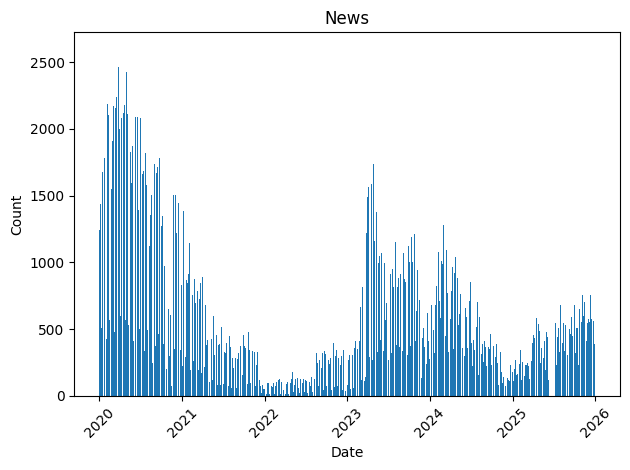

In [3]:
files = DAILY_DIRECTORY.glob("*.parquet")
df = pl.scan_parquet(files)

fin_df = (
    df
    .filter(
        pl.any_horizontal(
            pl.col("source").str.contains("cnbc.com|reuters.com|(?:^|\\.)bloomberg.com"),
            (pl.col("url").str.contains("finance\\.yahoo") & pl.col("source").str.contains("yahoo.com"))
        )
    )
    .with_columns(
        pl.col("datetime").dt.date().alias("date")
    )
)

daily_counts = (
    fin_df
    .group_by("date")
    .len()
    .sort("date")
)

result = daily_counts.collect(engine="streaming")

print(fin_df.group_by("source").len().sort(by="len", descending=True).collect(engine="streaming"))

plt.bar(result["date"], result["len"])
plt.title("News")
plt.xticks(rotation=45)
plt.xlabel("Date")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

shape: (6, 2)
┌───────────────────────┬───────┐
│ source                ┆ len   │
│ ---                   ┆ ---   │
│ str                   ┆ u32   │
╞═══════════════════════╪═══════╡
│ reuters.com           ┆ 21000 │
│ yahoo.com             ┆ 15343 │
│ bloomberg.com         ┆ 1336  │
│ cnbc.com              ┆ 1151  │
│ thomsonreuters.com    ┆ 3     │
│ thomsonreuters.com.au ┆ 1     │
└───────────────────────┴───────┘


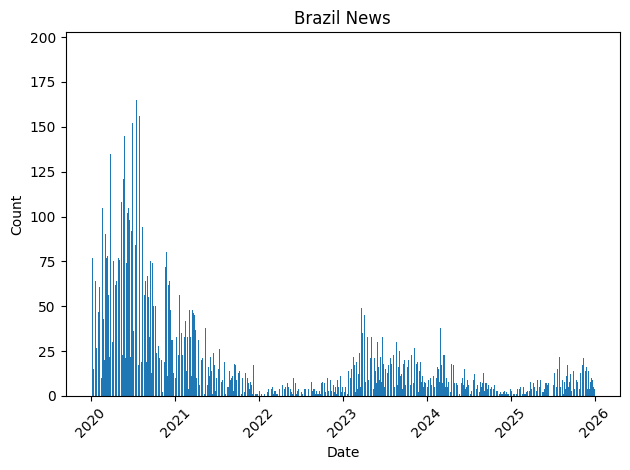

In [4]:
FILTERED_BRAZIL_PATH = Path("brazil_news")
FILTERED_BRAZIL_PATH.mkdir(exist_ok=True)

if not (FILTERED_BRAZIL_PATH / "brazil.parquet").exists():
    brazil_news = (
        fin_df
        .filter(
            pl.any_horizontal(
                pl.col("locations", "url", "themes", "v2themes", "title").str.contains_any(["brazil"], ascii_case_insensitive=True)
            )
        )
        .drop("date")
        .drop_nulls("title")
        .collect(engine="streaming")
    )

    brazil_news.write_parquet(FILTERED_BRAZIL_PATH / "brazil.parquet")

brazil_news = pl.read_parquet(FILTERED_BRAZIL_PATH / "brazil.parquet")

brazil_counts = (
    brazil_news
    .with_columns(
        pl.col("datetime").dt.date().alias("date")
    )
    .group_by("date")
    .len()
)

print(brazil_news.group_by("source").len().sort(by="len", descending=True))

plt.bar(brazil_counts["date"], brazil_counts["len"])
plt.title("Brazil News")
plt.xticks(rotation=45)
plt.xlabel("Date")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Modeling

## Use finBERT to extract sentiment from title column

In [5]:
MODEL = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)
device = torch.device("cpu")
model.to(device)
model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [6]:
labels = ("negative", "neutral", "positive")

In [7]:
def predict_sentiment(texts: list[str], batch_size=32):

    results: list[dict[str, float]] = []

    for i in range(0, len(texts), batch_size):

        batch = texts[i:i+batch_size]

        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)

        probs = F.softmax(outputs.logits, dim=1).cpu()

        for p in probs:
            results.append({
                "negative": p[0],
                "neutral": p[1],
                "positive": p[2],
                "sentiment_score": p[2] - p[0]
            })

    return results

In [8]:
if not "sentiment_score" in brazil_news.columns:

    titles = brazil_news["title"].to_list()

    sentiments = []

    BATCH_SIZE = 2048

    for i in tqdm(range(0, len(titles), BATCH_SIZE)):
        batch = titles[i:i+BATCH_SIZE]
        sentiments.extend(predict_sentiment(batch))
    
    sentiment_df = pl.DataFrame(sentiments)

    brazil_news = brazil_news.with_columns(sentiment_df)
    brazil_news.write_parquet(FILTERED_BRAZIL_PATH /  "brazil.parquet")

brazil_news = pl.read_parquet(FILTERED_BRAZIL_PATH /  "brazil.parquet")

## Download IBOVESPA from 2020 until 2025

In [9]:
ibov = pl.from_pandas(yf.download("^BVSP", start="2020-01-01", end="2026-01-01", progress=False, multi_level_index=False).reset_index())
ibov = ibov.rename({col:col.lower() for col in ibov.columns})

ibov = ibov.with_columns([
    pl.col("date").cast(pl.Date),
])

## Feature Engineering

In [10]:
# Aggregate Brazil news daily

daily_news = (
    brazil_news.with_columns(
        pl.col("datetime").dt.date().alias("date")
    )
    .group_by("date")
    .agg([
        pl.len().alias("news_volume"),

        pl.col("sentiment_score").mean().alias("sentiment_mean"),
        pl.col("sentiment_score").std().alias("sentiment_std"),

        pl.col("positive").mean().alias("positive_mean"),
        pl.col("negative").mean().alias("negative_mean"),
        pl.col("neutral").mean().alias("neutral_mean"),

        pl.col("sentiment_score").sum().alias("sentiment_sum"),

        pl.col("tone").mean().alias("tone"),
    ])
    .sort("date")
)

dataset = (
    ibov
    .join(daily_news, on="date", how="left")
    .sort("date")
)

dataset = (
    dataset
    .with_columns(
        (
            pl.col("close") / pl.col("close").shift(1) - 1
        ).alias("return")
))

# Set target columns equal to return on T+1 and Direction on T+1

dataset = (
    dataset.with_columns([
        pl.col("return").shift(-1).alias("target_return"),
        (pl.col("return").shift(-1) > 0).cast(pl.Int8).alias("target_direction")
    ])
)

# Open/High/Low/Close features

dataset = dataset.with_columns([

    # intraday range
    ((pl.col("high") - pl.col("low")) / pl.col("close"))
    .alias("range"),

    # open-close return
    ((pl.col("close") - pl.col("open")) / pl.col("open"))
    .alias("oc_return"),

    # overnight gap
    ((pl.col("open") - pl.col("close").shift(1)) / pl.col("close").shift(1))
    .alias("overnight_return")

])

# Volatility features

dataset = dataset.with_columns([

    pl.col("return").rolling_std(3).alias("volatility_3d"),
    pl.col("return").rolling_std(5).alias("volatility_5d"),
    pl.col("return").rolling_std(7).alias("volatility_7d"),

])

# Sentiment imbalance and intensity features

dataset = (
    dataset.with_columns([
        (pl.col("positive_mean") - pl.col("negative_mean"))
        .alias("sentiment_imbalance"),

        (pl.col("positive_mean") + pl.col("negative_mean"))
        .alias("sentiment_intensity"),
    ])
)

# Create sentiment imbalance and sentiment sum momentum features

dataset = dataset.with_columns([
    pl.col("sentiment_imbalance")
    .rolling_mean(3)
    .alias("sentiment_imbalance_3d"),

    pl.col("sentiment_imbalance")
    .rolling_mean(5)
    .alias("sentiment_imbalance_5d"),

    pl.col("sentiment_sum")
    .rolling_mean(7)
    .alias("sentiment_sum_7d"),
])

# News volume features

dataset = dataset.with_columns([

    (pl.col("news_volume") + 1).log()
    .alias("log_news_volume"),

    pl.col("news_volume")
    .rolling_mean(5)
    .alias("news_volume_5d")

])

# Create shock features

dataset = dataset.with_columns([

    (pl.col("sentiment_imbalance") - pl.col("sentiment_imbalance_3d"))
    .alias("sentiment_shock"),

    (pl.col("log_news_volume") - pl.col("news_volume_5d"))
    .alias("news_volume_shock")

])

# Create return momentum features

dataset = dataset.with_columns([

    pl.col("return").rolling_mean(3).alias("momentum_3d"),
    pl.col("return").rolling_mean(5).alias("momentum_5d"),
    pl.col("return").rolling_mean(7).alias("momentum_7d"),

])

# Create close price trend and drawdown features

dataset = dataset.with_columns([

    pl.col("close").rolling_mean(20).alias("close_moving_average_20d"),
    pl.col("close").rolling_max(20).alias("close_high_20d")

])

dataset = dataset.with_columns([

    (pl.col("close") / pl.col("close_moving_average_20d") - 1)
    .alias("trend20"),

    (pl.col("close") / pl.col("close_high_20d") - 1)
    .alias("drawdown20")

])

# Create lagged features

lag_cols = [
    "sentiment_imbalance",
    "sentiment_shock",
    "news_volume_shock"
]

for col in lag_cols:
    for lag in range(1, 4):
        dataset = dataset.with_columns(
            pl.col(col).shift(lag).alias(f"{col}_lag_{lag}d")
        )

# Lag news features to prevent look-ahead

news_cols = [
    col for col in dataset.columns if 
        ("news" in col) or
        ("sentiment" in col) or
        ("neutral" in col) or 
        ("positive" in col) or 
        ("negative" in col)
]

pdf = dataset.with_columns([
    pl.col(c).shift(1) for c in news_cols
]).drop_nulls().to_pandas()

### Select features for training and prediction

In [11]:
sentiment_features = [

    "sentiment_imbalance",
    "sentiment_intensity",
    "sentiment_imbalance_5d",
    "sentiment_imbalance_3d",
    "sentiment_sum_7d",
    "sentiment_shock",

    "log_news_volume",
    "news_volume_shock",

    "sentiment_imbalance_lag_1d",
    "sentiment_imbalance_lag_2d",
    "sentiment_imbalance_lag_3d",

    "sentiment_shock_lag_1d",
    "sentiment_shock_lag_2d",
    "sentiment_shock_lag_3d",
]

gdelt_tone_features = [
    "tone"
]

price_features = [

    "momentum_3d",
    "momentum_5d",
    "momentum_7d",

    "volatility_3d",
    "volatility_5d",
    "volatility_7d",

    "trend20",
    "drawdown20",
]

### Create functions to run the classification and regression

In [12]:
tscv = TimeSeriesSplit(n_splits=5)
def run_classification(model, X, y):
    fold_metrics = []
    y_true, y_pred, all_proba = [], [], []

    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        proba = model.predict_proba(X_test)[:, 1]

        fold_metrics.append({
            "accuracy": accuracy_score(y_test, pred),
            "f1": f1_score(y_test, pred),
            "roc_auc": roc_auc_score(y_test, proba),
        })

        y_true.append(y_test)
        y_pred.append(pred)
        all_proba.append(proba)

    fold_df = pd.DataFrame(fold_metrics)
    overall = {
        "accuracy_mean": fold_df["accuracy"].mean(),
        "accuracy_std": fold_df["accuracy"].std(),
        "f1_mean": fold_df["f1"].mean(),
        "f1_std": fold_df["f1"].std(),
        "roc_auc_mean": fold_df["roc_auc"].mean(),
        "roc_auc_std": fold_df["roc_auc"].std(),
    }

    return overall, pd.concat(y_true), np.concatenate(y_pred), np.concatenate(all_proba)


def run_regression(model, X, y):
    fold_metrics = []
    y_true, y_pred = [], []

    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        fold_metrics.append({
            "rmse": root_mean_squared_error(y_test, pred),
            "mae": mean_absolute_error(y_test, pred),
            "r2": r2_score(y_test, pred),
        })

        y_true.append(y_test)
        y_pred.append(pred)

    fold_df = pd.DataFrame(fold_metrics)
    overall = {
        "rmse_mean": fold_df["rmse"].mean(),
        "rmse_std": fold_df["rmse"].std(),
        "mae_mean": fold_df["mae"].mean(),
        "mae_std": fold_df["mae"].std(),
        "r2_mean": fold_df["r2"].mean(),
        "r2_std": fold_df["r2"].std(),
    }

    return overall, pd.concat(y_true), np.concatenate(y_pred)

## Evaluating models with all features

In [13]:
y_dir = pdf["target_direction"]
y_ret = pdf["target_return"]

### Testing only return

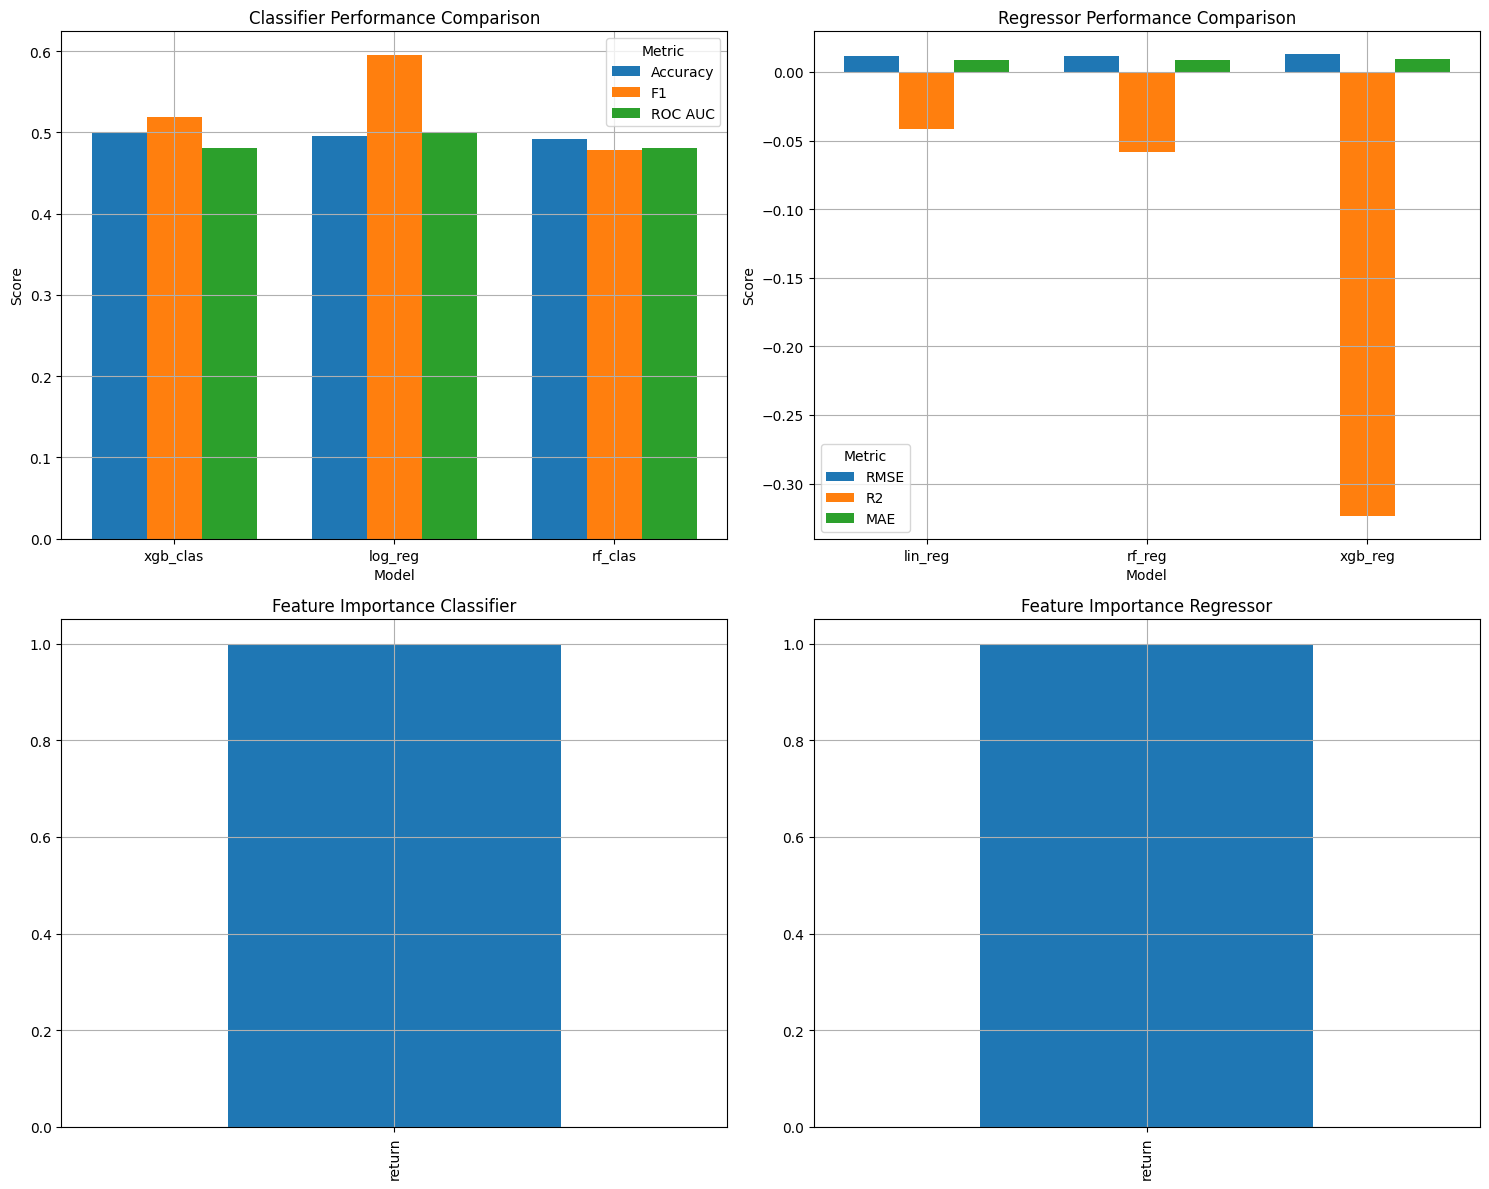

In [14]:
X = pdf[["return"]]
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)
plt.figure(figsize=(15, 12))

classifier_results = []
classifier_models = {
    "log_reg": LogisticRegression(max_iter=2000),
    "rf_clas": RandomForestClassifier(
        n_estimators=500,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    ),
    "xgb_clas": XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
    ),
}

for name, model in classifier_models.items():
    res = {"model": name}
    res.update(run_classification(model, X_scaled, y_dir)[0])
    classifier_results.append(res)

df = pl.DataFrame(classifier_results).sort(by="accuracy_mean", descending=True).to_pandas()

x = np.arange(len(df))
width = 0.25

plt.subplot(2, 2, 1)
plt.bar(x - width, df["accuracy_mean"], width, label="Accuracy")
plt.bar(x, df["f1_mean"], width, label="F1")
plt.bar(x + width, df["roc_auc_mean"], width, label="ROC AUC")

plt.xticks(x, df["model"])
plt.xlabel("Model")
plt.ylabel("Score")
plt.legend()
plt.ylabel("Score")
plt.title("Classifier Performance Comparison")
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid()

regressor_results = []
regressor_models = {
    "lin_reg": LinearRegression(n_jobs=-1),
    "rf_reg": RandomForestRegressor(
        n_estimators=500,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    ),
    "xgb_reg": XGBRegressor(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.03,
    ),
}

for name, model in regressor_models.items():
    res = {"model": name}
    res.update(run_regression(model, X_scaled, y_ret)[0])
    regressor_results.append(res)

df = pl.DataFrame(regressor_results).sort(by="r2_mean", descending=True).to_pandas()

x = np.arange(len(df))
width = 0.25

plt.subplot(2, 2, 2)
plt.bar(x - width, df["rmse_mean"], width, label="RMSE")
plt.bar(x, df["r2_mean"], width, label="R2")
plt.bar(x + width, df["mae_mean"], width, label="MAE")

plt.xticks(x, df["model"])
plt.xlabel("Model")
plt.ylabel("Score")
plt.legend()
plt.ylabel("Score")
plt.title("Regressor Performance Comparison")
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid()

importance = pd.Series(
    classifier_models["xgb_clas"].feature_importances_,
    index=["return"]
).sort_values(ascending=False)

plt.subplot(2, 2, 3)
importance.head(15).plot.bar()
plt.title("Feature Importance Classifier")
plt.grid()

importance = pd.Series(
    regressor_models["xgb_reg"].feature_importances_,
    index=["return"]
).sort_values(ascending=False)

plt.subplot(2, 2, 4)
importance.head(15).plot.bar()
plt.title("Feature Importance Regressor")
plt.grid()

plt.tight_layout()
plt.show()

### Testing only sentiment score

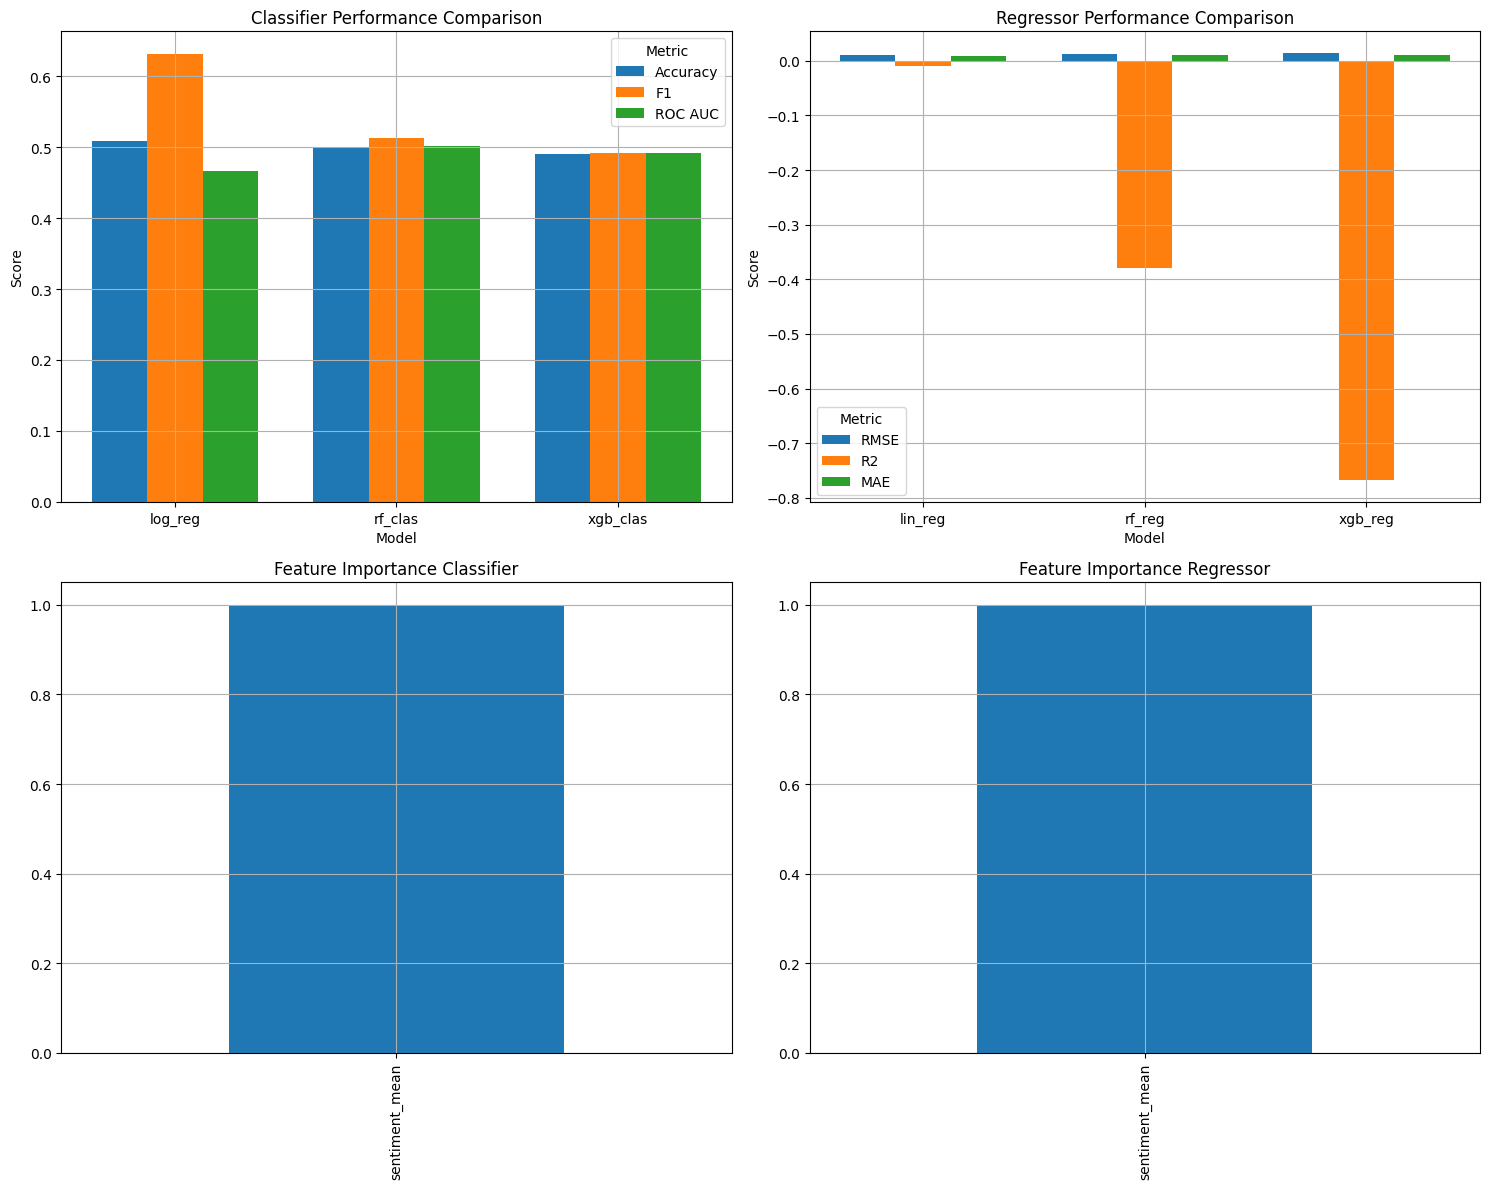

In [15]:
X = pdf[["sentiment_mean"]]
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)
plt.figure(figsize=(15, 12))

classifier_results = []
classifier_models = {
    "log_reg": LogisticRegression(max_iter=2000),
    "rf_clas": RandomForestClassifier(
        n_estimators=500,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    ),
    "xgb_clas": XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
    ),
}

for name, model in classifier_models.items():
    res = {"model": name}
    res.update(run_classification(model, X_scaled, y_dir)[0])
    classifier_results.append(res)

df = pl.DataFrame(classifier_results).sort(by="accuracy_mean", descending=True).to_pandas()

x = np.arange(len(df))
width = 0.25

plt.subplot(2, 2, 1)
plt.bar(x - width, df["accuracy_mean"], width, label="Accuracy")
plt.bar(x, df["f1_mean"], width, label="F1")
plt.bar(x + width, df["roc_auc_mean"], width, label="ROC AUC")

plt.xticks(x, df["model"])
plt.xlabel("Model")
plt.ylabel("Score")
plt.legend()
plt.ylabel("Score")
plt.title("Classifier Performance Comparison")
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid()

regressor_results = []
regressor_models = {
    "lin_reg": LinearRegression(n_jobs=-1),
    "rf_reg": RandomForestRegressor(
        n_estimators=500,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    ),
    "xgb_reg": XGBRegressor(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.03,
    ),
}

for name, model in regressor_models.items():
    res = {"model": name}
    res.update(run_regression(model, X_scaled, y_ret)[0])
    regressor_results.append(res)

df = pl.DataFrame(regressor_results).sort(by="r2_mean", descending=True).to_pandas()

x = np.arange(len(df))
width = 0.25

plt.subplot(2, 2, 2)
plt.bar(x - width, df["rmse_mean"], width, label="RMSE")
plt.bar(x, df["r2_mean"], width, label="R2")
plt.bar(x + width, df["mae_mean"], width, label="MAE")

plt.xticks(x, df["model"])
plt.xlabel("Model")
plt.ylabel("Score")
plt.legend()
plt.ylabel("Score")
plt.title("Regressor Performance Comparison")
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid()

importance = pd.Series(
    classifier_models["xgb_clas"].feature_importances_,
    index=["sentiment_mean"]
).sort_values(ascending=False)

plt.subplot(2, 2, 3)
importance.head(15).plot.bar()
plt.title("Feature Importance Classifier")
plt.grid()

importance = pd.Series(
    regressor_models["xgb_reg"].feature_importances_,
    index=["sentiment_mean"]
).sort_values(ascending=False)

plt.subplot(2, 2, 4)
importance.head(15).plot.bar()
plt.title("Feature Importance Regressor")
plt.grid()

plt.tight_layout()
plt.show()

### Testing only tone

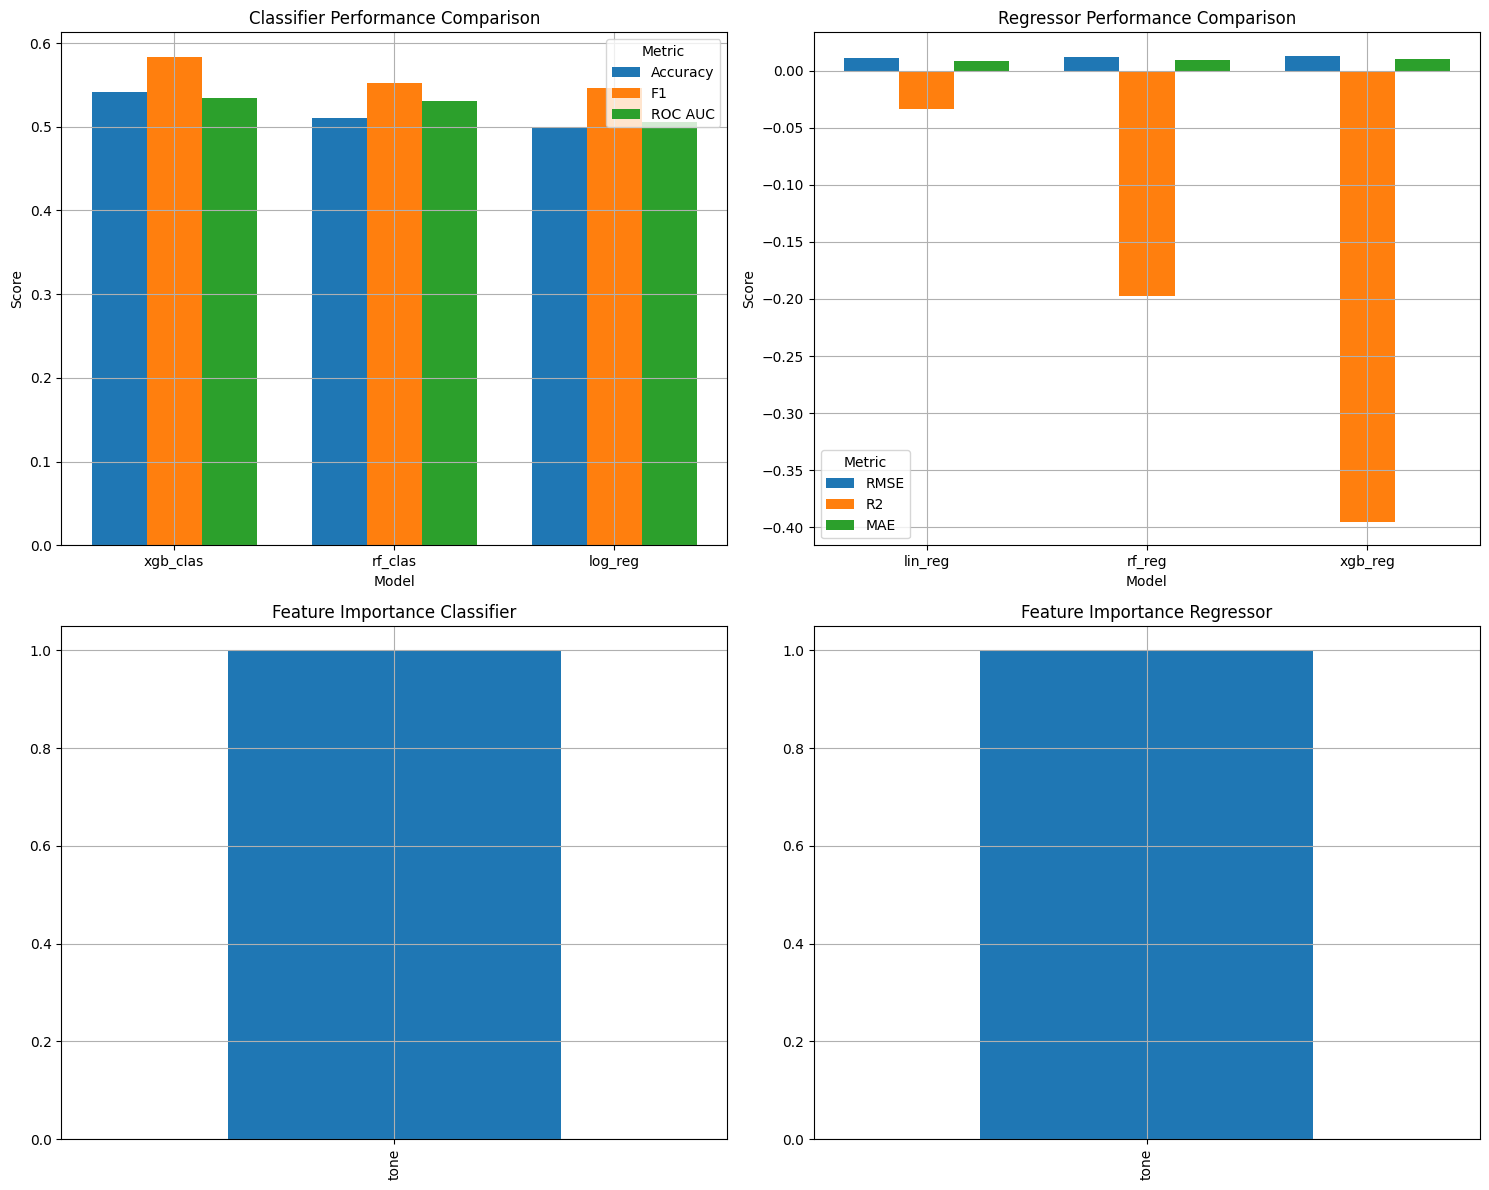

In [35]:
X = pdf[gdelt_tone_features]
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)
plt.figure(figsize=(15, 12))

classifier_results = []
classifier_models = {
    "log_reg": LogisticRegression(max_iter=2000),
    "rf_clas": RandomForestClassifier(
        n_estimators=500,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    ),
    "xgb_clas": XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
    ),
}

for name, model in classifier_models.items():
    res = {"model": name}
    res.update(run_classification(model, X_scaled, y_dir)[0])
    classifier_results.append(res)

df = pl.DataFrame(classifier_results).sort(by="accuracy_mean", descending=True).to_pandas()

x = np.arange(len(df))
width = 0.25

plt.subplot(2, 2, 1)
plt.bar(x - width, df["accuracy_mean"], width, label="Accuracy")
plt.bar(x, df["f1_mean"], width, label="F1")
plt.bar(x + width, df["roc_auc_mean"], width, label="ROC AUC")

plt.xticks(x, df["model"])
plt.xlabel("Model")
plt.ylabel("Score")
plt.legend()
plt.ylabel("Score")
plt.title("Classifier Performance Comparison")
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid()

regressor_results = []
regressor_models = {
    "lin_reg": LinearRegression(n_jobs=-1),
    "rf_reg": RandomForestRegressor(
        n_estimators=500,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    ),
    "xgb_reg": XGBRegressor(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.03,
    ),
}

for name, model in regressor_models.items():
    res = {"model": name}
    res.update(run_regression(model, X_scaled, y_ret)[0])
    regressor_results.append(res)

df = pl.DataFrame(regressor_results).sort(by="r2_mean", descending=True).to_pandas()

x = np.arange(len(df))
width = 0.25

plt.subplot(2, 2, 2)
plt.bar(x - width, df["rmse_mean"], width, label="RMSE")
plt.bar(x, df["r2_mean"], width, label="R2")
plt.bar(x + width, df["mae_mean"], width, label="MAE")

plt.xticks(x, df["model"])
plt.xlabel("Model")
plt.ylabel("Score")
plt.legend()
plt.ylabel("Score")
plt.title("Regressor Performance Comparison")
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid()

importance = pd.Series(
    classifier_models["xgb_clas"].feature_importances_,
    index=gdelt_tone_features
).sort_values(ascending=False)

plt.subplot(2, 2, 3)
importance.head(15).plot.bar()
plt.title("Feature Importance Classifier")
plt.grid()

importance = pd.Series(
    regressor_models["xgb_reg"].feature_importances_,
    index=gdelt_tone_features
).sort_values(ascending=False)

plt.subplot(2, 2, 4)
importance.head(15).plot.bar()
plt.title("Feature Importance Regressor")
plt.grid()

plt.tight_layout()
plt.show()

### Testing all sentiment related features

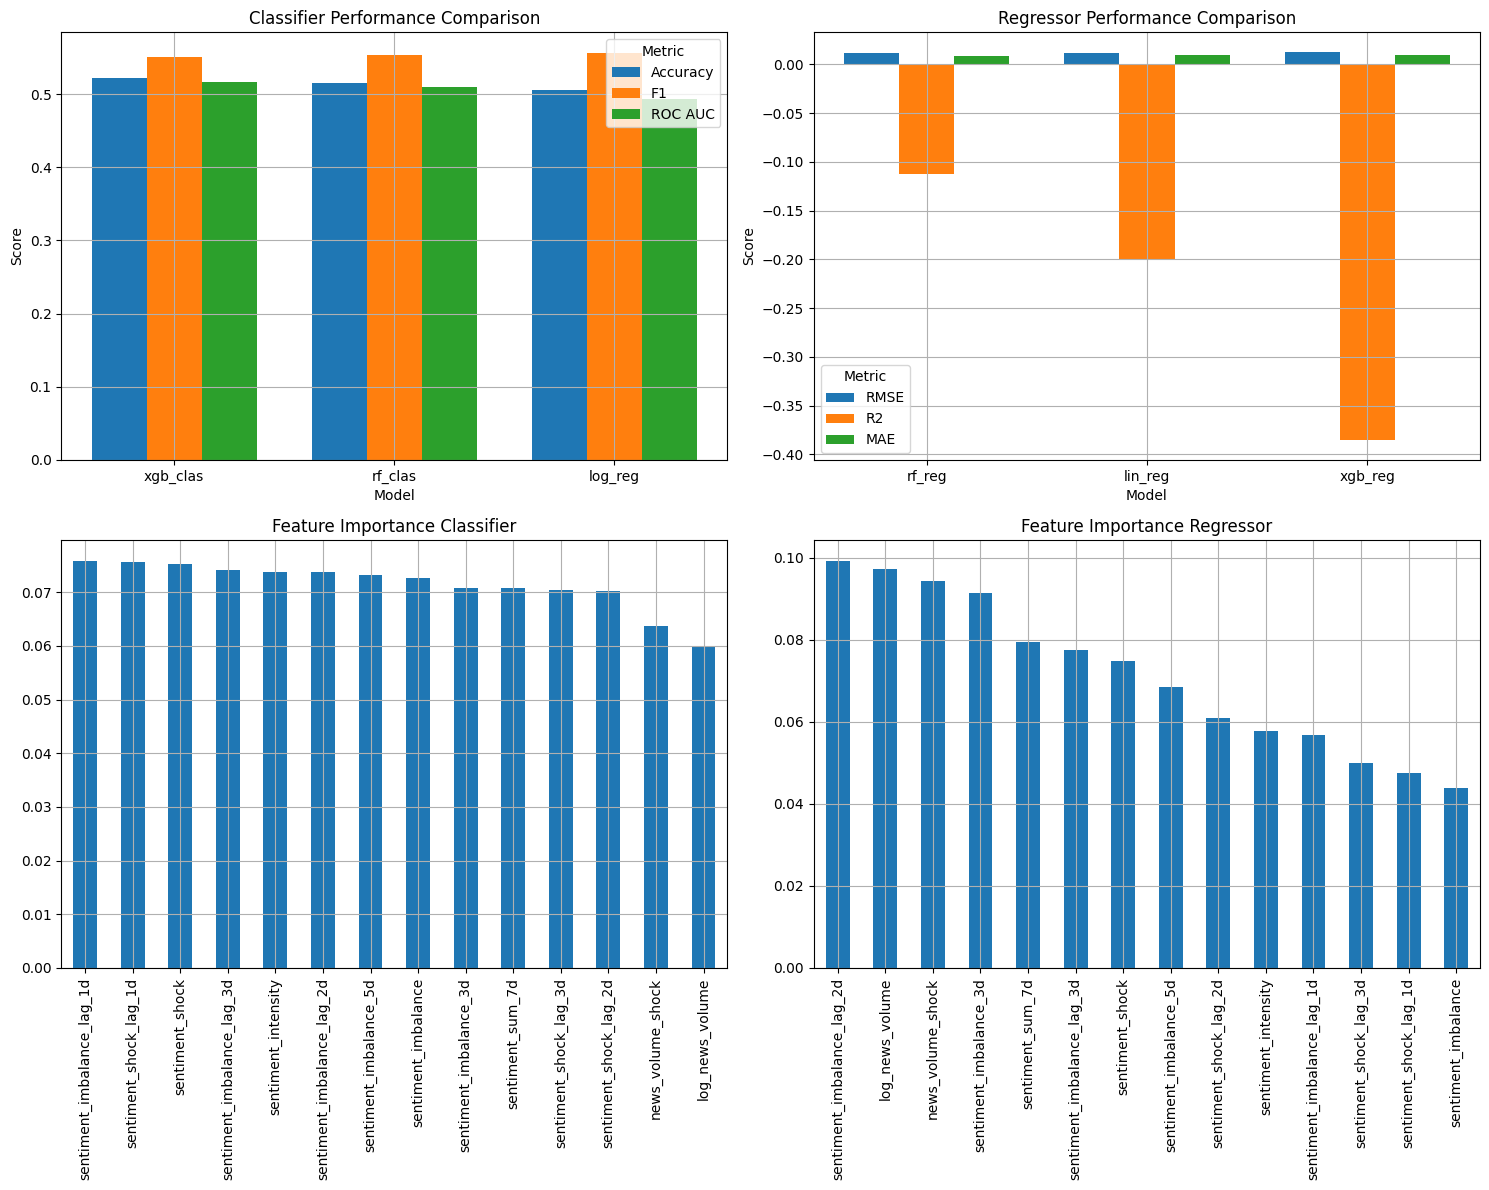

In [36]:
X = pdf[sentiment_features]
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)
plt.figure(figsize=(15, 12))

classifier_results = []
classifier_models = {
    "log_reg": LogisticRegression(max_iter=2000),
    "rf_clas": RandomForestClassifier(
        n_estimators=500,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    ),
    "xgb_clas": XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
    ),
}

for name, model in classifier_models.items():
    res = {"model": name}
    res.update(run_classification(model, X_scaled, y_dir)[0])
    classifier_results.append(res)

df = pl.DataFrame(classifier_results).sort(by="accuracy_mean", descending=True).to_pandas()

x = np.arange(len(df))
width = 0.25

plt.subplot(2, 2, 1)
plt.bar(x - width, df["accuracy_mean"], width, label="Accuracy")
plt.bar(x, df["f1_mean"], width, label="F1")
plt.bar(x + width, df["roc_auc_mean"], width, label="ROC AUC")

plt.xticks(x, df["model"])
plt.xlabel("Model")
plt.ylabel("Score")
plt.legend()
plt.ylabel("Score")
plt.title("Classifier Performance Comparison")
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid()

regressor_results = []
regressor_models = {
    "lin_reg": LinearRegression(n_jobs=-1),
    "rf_reg": RandomForestRegressor(
        n_estimators=500,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    ),
    "xgb_reg": XGBRegressor(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.03,
    ),
}

for name, model in regressor_models.items():
    res = {"model": name}
    res.update(run_regression(model, X_scaled, y_ret)[0])
    regressor_results.append(res)

df = pl.DataFrame(regressor_results).sort(by="r2_mean", descending=True).to_pandas()

x = np.arange(len(df))
width = 0.25

plt.subplot(2, 2, 2)
plt.bar(x - width, df["rmse_mean"], width, label="RMSE")
plt.bar(x, df["r2_mean"], width, label="R2")
plt.bar(x + width, df["mae_mean"], width, label="MAE")

plt.xticks(x, df["model"])
plt.xlabel("Model")
plt.ylabel("Score")
plt.legend()
plt.ylabel("Score")
plt.title("Regressor Performance Comparison")
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid()

importance = pd.Series(
    classifier_models["xgb_clas"].feature_importances_,
    index=sentiment_features
).sort_values(ascending=False)

plt.subplot(2, 2, 3)
importance.head(15).plot.bar()
plt.title("Feature Importance Classifier")
plt.grid()

importance = pd.Series(
    regressor_models["xgb_reg"].feature_importances_,
    index=sentiment_features
).sort_values(ascending=False)

plt.subplot(2, 2, 4)
importance.head(15).plot.bar()
plt.title("Feature Importance Regressor")
plt.grid()

plt.tight_layout()
plt.show()

### Testing all price related features

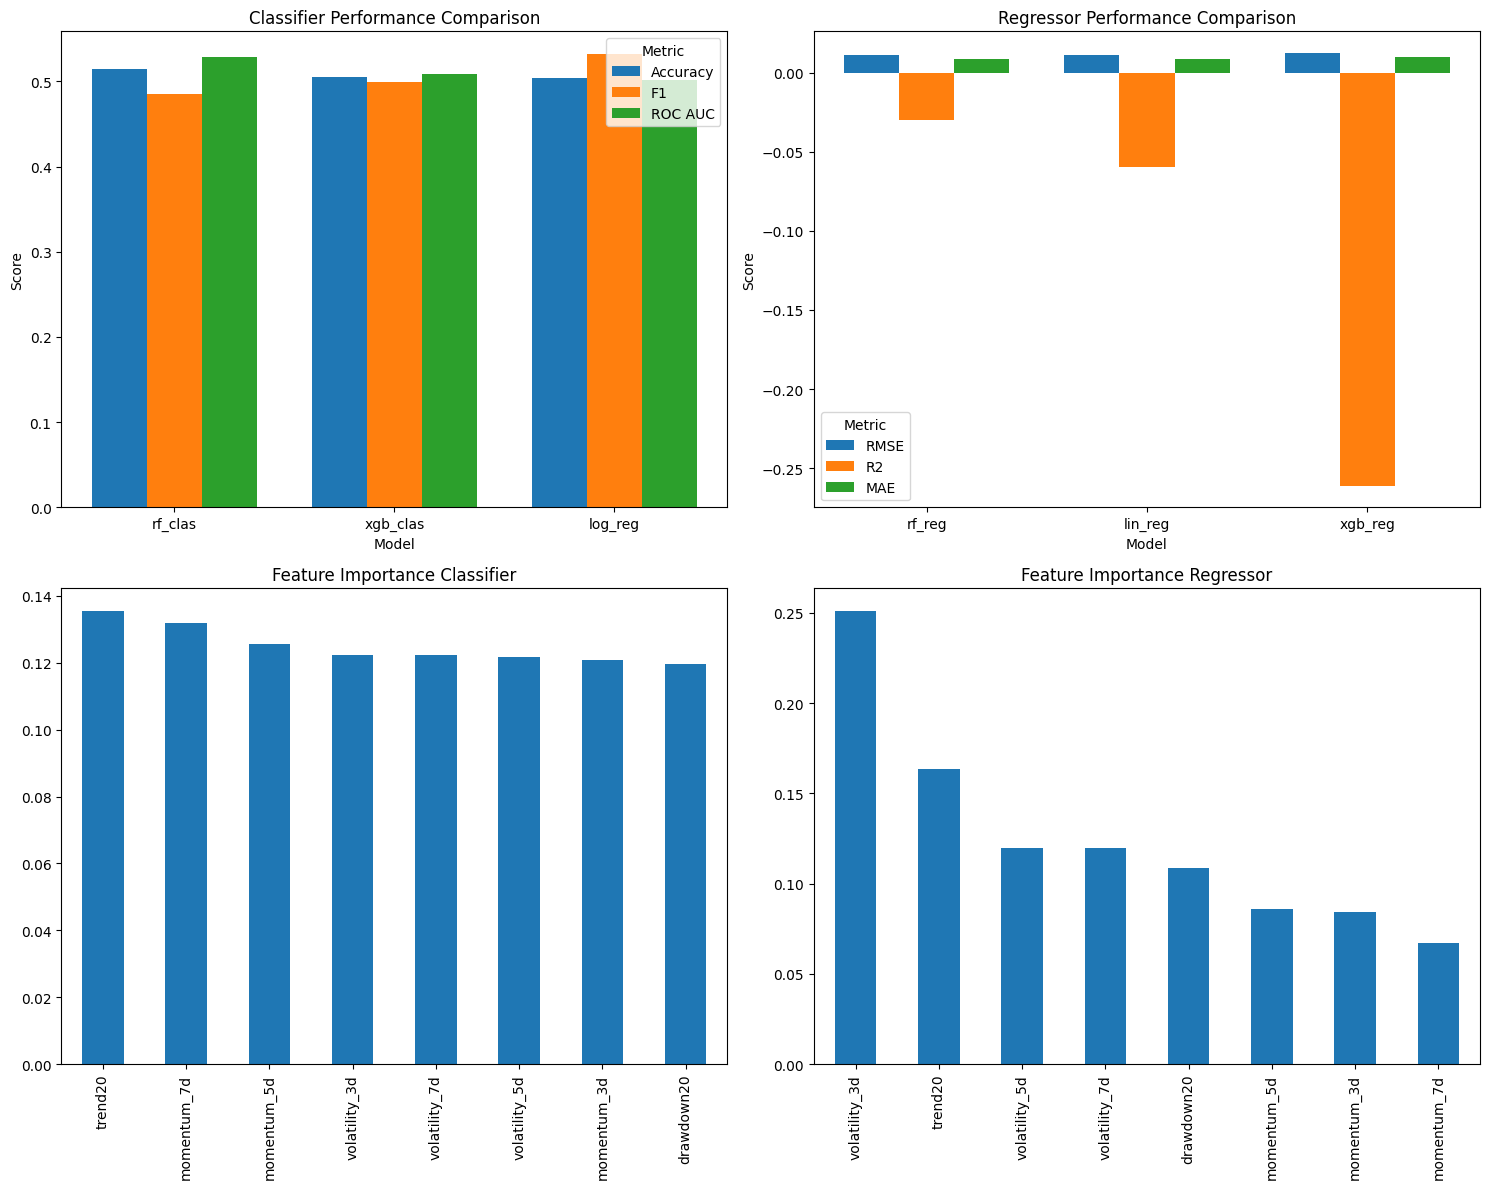

In [ ]:
X = pdf[price_features]
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)
plt.figure(figsize=(15, 12))

classifier_results = []
classifier_models = {
    "log_reg": LogisticRegression(max_iter=2000),
    "rf_clas": RandomForestClassifier(
        n_estimators=500,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    ),
    "xgb_clas": XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
    ),
}

for name, model in classifier_models.items():
    res = {"model": name}
    res.update(run_classification(model, X_scaled, y_dir)[0])
    classifier_results.append(res)

df = pl.DataFrame(classifier_results).sort(by="accuracy_mean", descending=True).to_pandas()

x = np.arange(len(df))
width = 0.25

plt.subplot(2, 2, 1)
plt.bar(x - width, df["accuracy_mean"], width, label="Accuracy")
plt.bar(x, df["f1_mean"], width, label="F1")
plt.bar(x + width, df["roc_auc_mean"], width, label="ROC AUC")

plt.xticks(x, df["model"])
plt.xlabel("Model")
plt.ylabel("Score")
plt.legend()
plt.ylabel("Score")
plt.title("Classifier Performance Comparison")
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid()

regressor_results = []
regressor_models = {
    "lin_reg": LinearRegression(n_jobs=-1),
    "rf_reg": RandomForestRegressor(
        n_estimators=500,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    ),
    "xgb_reg": XGBRegressor(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.03,
    ),
}

for name, model in regressor_models.items():
    res = {"model": name}
    res.update(run_regression(model, X_scaled, y_ret)[0])
    regressor_results.append(res)

df = pl.DataFrame(regressor_results).sort(by="r2_mean", descending=True).to_pandas()

x = np.arange(len(df))
width = 0.25

plt.subplot(2, 2, 2)
plt.bar(x - width, df["rmse_mean"], width, label="RMSE")
plt.bar(x, df["r2_mean"], width, label="R2")
plt.bar(x + width, df["mae_mean"], width, label="MAE")

plt.xticks(x, df["model"])
plt.xlabel("Model")
plt.ylabel("Score")
plt.legend()
plt.ylabel("Score")
plt.title("Regressor Performance Comparison")
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid()

importance = pd.Series(
    classifier_models["xgb_clas"].feature_importances_,
    index=price_features
).sort_values(ascending=False)

plt.subplot(2, 2, 3)
importance.head(15).plot.bar()
plt.title("Feature Importance Classifier")
plt.grid()

importance = pd.Series(
    regressor_models["xgb_reg"].feature_importances_,
    index=price_features
).sort_values(ascending=False)

plt.subplot(2, 2, 4)
importance.head(15).plot.bar()
plt.title("Feature Importance Regressor")
plt.grid()

plt.tight_layout()
plt.show()

### Testing sentiment, tone and price features

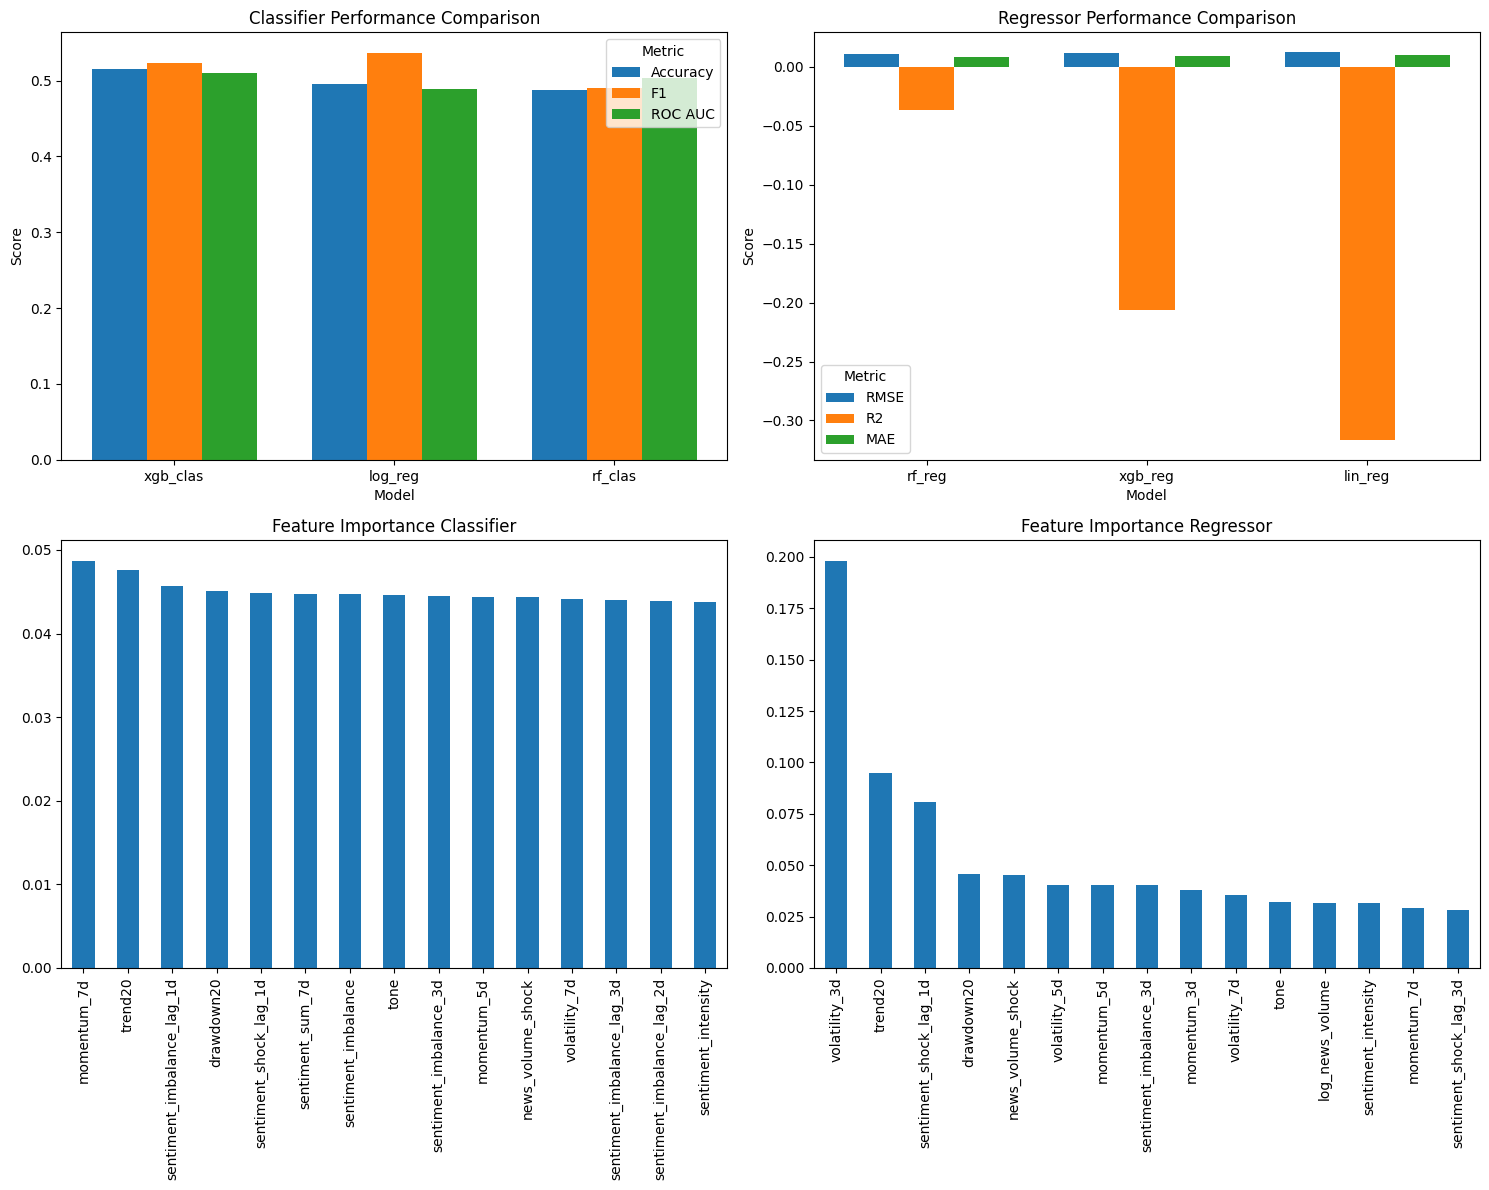

In [ ]:
X = pdf[sentiment_features + gdelt_tone_features + price_features]
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)
plt.figure(figsize=(15, 12))

classifier_results = []
classifier_models = {
    "log_reg": LogisticRegression(max_iter=2000),
    "rf_clas": RandomForestClassifier(
        n_estimators=500,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    ),
    "xgb_clas": XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
    ),
}

for name, model in classifier_models.items():
    res = {"model": name}
    res.update(run_classification(model, X_scaled, y_dir)[0])
    classifier_results.append(res)

df = pl.DataFrame(classifier_results).sort(by="accuracy_mean", descending=True).to_pandas()

x = np.arange(len(df))
width = 0.25

plt.subplot(2, 2, 1)
plt.bar(x - width, df["accuracy_mean"], width, label="Accuracy")
plt.bar(x, df["f1_mean"], width, label="F1")
plt.bar(x + width, df["roc_auc_mean"], width, label="ROC AUC")

plt.xticks(x, df["model"])
plt.xlabel("Model")
plt.ylabel("Score")
plt.legend()
plt.ylabel("Score")
plt.title("Classifier Performance Comparison")
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid()

regressor_results = []
regressor_models = {
    "lin_reg": LinearRegression(n_jobs=-1),
    "rf_reg": RandomForestRegressor(
        n_estimators=500,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    ),
    "xgb_reg": XGBRegressor(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.03,
    ),
}

for name, model in regressor_models.items():
    res = {"model": name}
    res.update(run_regression(model, X_scaled, y_ret)[0])
    regressor_results.append(res)

df = pl.DataFrame(regressor_results).sort(by="r2_mean", descending=True).to_pandas()

x = np.arange(len(df))
width = 0.25

plt.subplot(2, 2, 2)
plt.bar(x - width, df["rmse_mean"], width, label="RMSE")
plt.bar(x, df["r2_mean"], width, label="R2")
plt.bar(x + width, df["mae_mean"], width, label="MAE")

plt.xticks(x, df["model"])
plt.xlabel("Model")
plt.ylabel("Score")
plt.legend()
plt.ylabel("Score")
plt.title("Regressor Performance Comparison")
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid()

importance = pd.Series(
    classifier_models["xgb_clas"].feature_importances_,
    index= sentiment_features + gdelt_tone_features + price_features
).sort_values(ascending=False)

plt.subplot(2, 2, 3)
importance.head(15).plot.bar()
plt.title("Feature Importance Classifier")
plt.grid()

importance = pd.Series(
    regressor_models["xgb_reg"].feature_importances_,
    index= sentiment_features + gdelt_tone_features + price_features
).sort_values(ascending=False)

plt.subplot(2, 2, 4)
importance.head(15).plot.bar()
plt.title("Feature Importance Regressor")
plt.grid()

plt.tight_layout()
plt.show()

## Removing features using Recursive Feature Elimination

In [20]:
def run_rfecv(model, X, y, scoring):
    selector = RFECV(
        estimator=model,
        step=1,
        cv=TimeSeriesSplit(n_splits=5),
        scoring=scoring,
        n_jobs=-1
    )
    selector.fit(X, y)
    return selector

def get_feature_importance(model, feature_names):
    if hasattr(model, "coef_"):
        imp = np.abs(model.coef_).flatten()
    elif hasattr(model, "feature_importances_"):
        imp = model.feature_importances_
    else:
        raise ValueError("Model does not expose feature importance")

    return pd.Series(imp, index=feature_names)

### Testing only sentiment related features

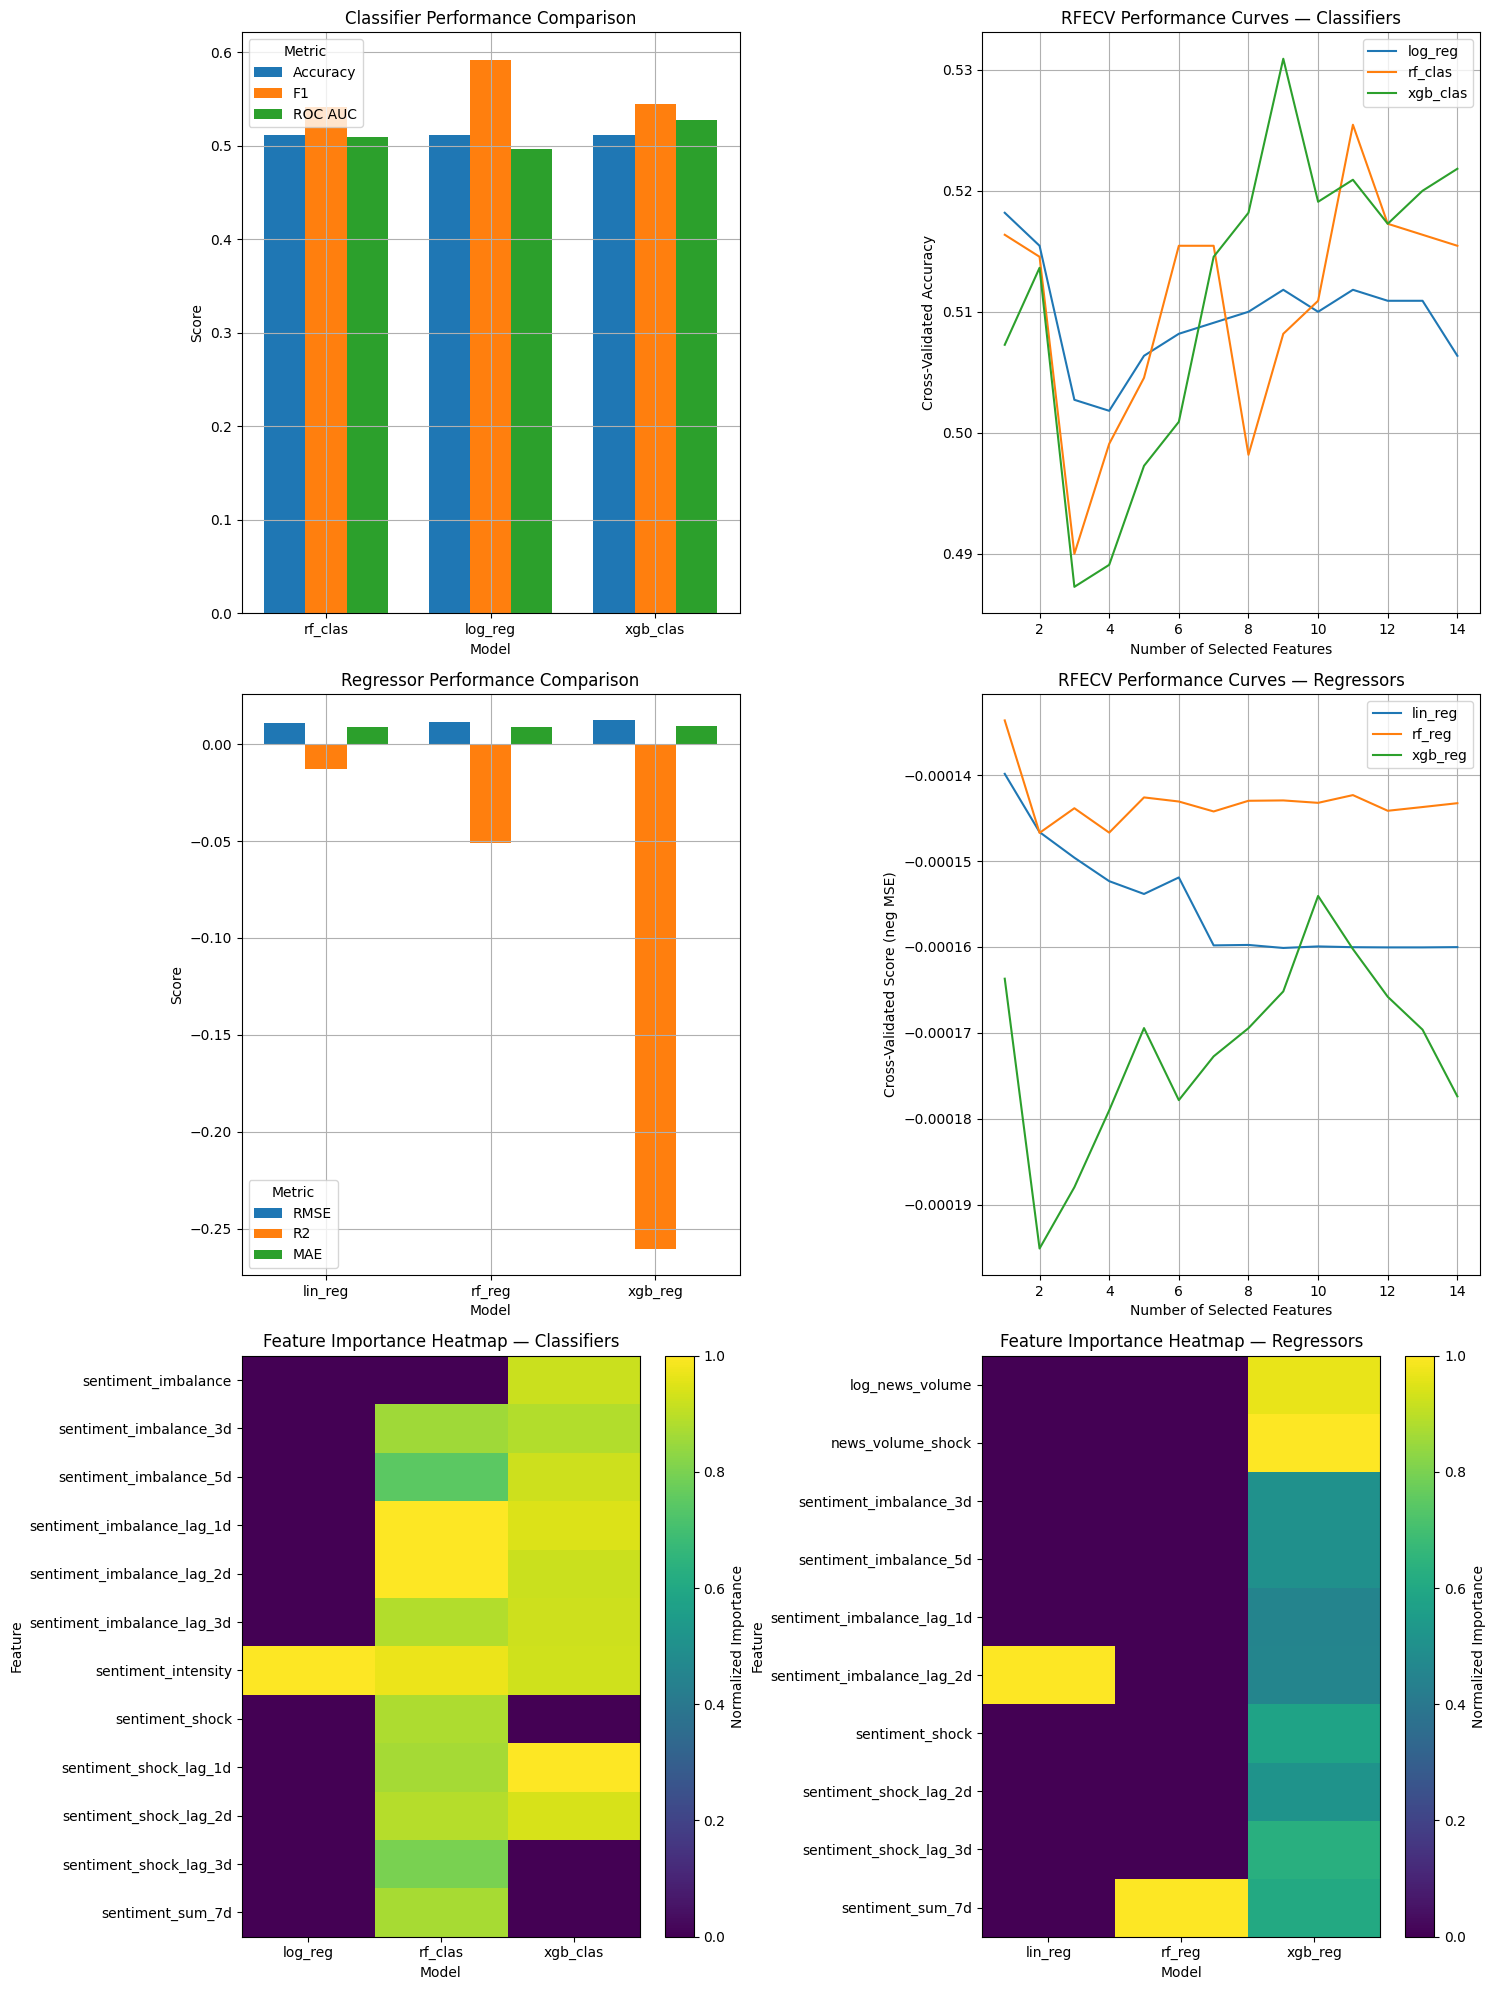

In [21]:
X = pdf[sentiment_features]
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

classifier_results = []
classifier_models = {
    "log_reg": LogisticRegression(max_iter=2000),
    "rf_clas": RandomForestClassifier(
        n_estimators=500,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    ),
    "xgb_clas": XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
    ),
}

rfecv_curves_clf = {}

for name, model in classifier_models.items():
    res = {"model": name}

    rfecv = run_rfecv(model, X_scaled, y_dir, scoring="accuracy")
    best_features = X_scaled.columns[rfecv.support_].tolist()

    model.best_features = best_features
    model.rfecv = rfecv
    rfecv_curves_clf[name] = rfecv.cv_results_["mean_test_score"]

    res.update(run_classification(model, X_scaled[best_features], y_dir)[0])
    classifier_results.append(res)

regressor_results = []
regressor_models = {
    "lin_reg": LinearRegression(),
    "rf_reg": RandomForestRegressor(
        n_estimators=500,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    ),
    "xgb_reg": XGBRegressor(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.03,
    ),
}

rfecv_curves_reg = {}

for name, model in regressor_models.items():
    res = {"model": name}

    rfecv = run_rfecv(model, X_scaled, y_ret, scoring="neg_mean_squared_error")
    best_features = X_scaled.columns[rfecv.support_].tolist()

    model.best_features = best_features
    model.rfecv = rfecv
    rfecv_curves_reg[name] = rfecv.cv_results_["mean_test_score"]

    res.update(run_regression(model, X_scaled[best_features], y_ret)[0])
    regressor_results.append(res)


plt.figure(figsize=(15, 20))

# Classifier plots

df = pl.DataFrame(classifier_results).sort(by="accuracy_mean", descending=True).to_pandas()

x = np.arange(len(df))
width = 0.25

plt.subplot(3, 2, 1)
plt.bar(x - width, df["accuracy_mean"], width, label="Accuracy")
plt.bar(x, df["f1_mean"], width, label="F1")
plt.bar(x + width, df["roc_auc_mean"], width, label="ROC AUC")

plt.xticks(x, df["model"])
plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Classifier Performance Comparison")
plt.legend(title="Metric")
plt.grid()

plt.subplot(3, 2, 2)
for name, scores in rfecv_curves_clf.items():
    plt.plot(range(1, len(scores) + 1), scores, label=name)

plt.title("RFECV Performance Curves — Classifiers")
plt.xlabel("Number of Selected Features")
plt.ylabel("Cross-Validated Accuracy")
plt.legend()
plt.grid()

# Regressor plots

df = pl.DataFrame(regressor_results).sort(by="r2_mean", descending=True).to_pandas()

x = np.arange(len(df))
width = 0.25

plt.subplot(3, 2, 3)
plt.bar(x - width, df["rmse_mean"], width, label="RMSE")
plt.bar(x, df["r2_mean"], width, label="R2")
plt.bar(x + width, df["mae_mean"], width, label="MAE")

plt.xticks(x, df["model"])
plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Regressor Performance Comparison")
plt.legend(title="Metric")
plt.grid()

plt.subplot(3, 2, 4)
for name, scores in rfecv_curves_reg.items():
    plt.plot(range(1, len(scores) + 1), scores, label=name)

plt.title("RFECV Performance Curves — Regressors")
plt.xlabel("Number of Selected Features")
plt.ylabel("Cross-Validated Score (neg MSE)")
plt.legend()
plt.grid()

# Feature importance heatmaps

for model in classifier_models.values():
    model.fit(X_scaled[model.best_features], y_dir)

for model in regressor_models.values():
    model.fit(X_scaled[model.best_features], y_ret)

clf_importance = {}

for name, model in classifier_models.items():
    imp = get_feature_importance(model, model.best_features)
    clf_importance[name] = imp

clf_imp_df = pd.DataFrame(clf_importance).fillna(0)

clf_imp_df = clf_imp_df / clf_imp_df.max()

plt.subplot(3, 2, 5)
plt.imshow(clf_imp_df.values, aspect="auto")

plt.yticks(range(len(clf_imp_df.index)), clf_imp_df.index)
plt.xticks(range(len(clf_imp_df.columns)), clf_imp_df.columns)

plt.title("Feature Importance Heatmap — Classifiers")
plt.xlabel("Model")
plt.ylabel("Feature")
plt.colorbar(label="Normalized Importance")
plt.tight_layout()

reg_importance = {}

for name, model in regressor_models.items():
    imp = get_feature_importance(model, model.best_features)
    reg_importance[name] = imp

reg_imp_df = pd.DataFrame(reg_importance).fillna(0)

reg_imp_df = reg_imp_df / reg_imp_df.max()

plt.subplot(3, 2, 6)
plt.imshow(reg_imp_df.values, aspect="auto")

plt.yticks(range(len(reg_imp_df.index)), reg_imp_df.index)
plt.xticks(range(len(reg_imp_df.columns)), reg_imp_df.columns)

plt.title("Feature Importance Heatmap — Regressors")
plt.xlabel("Model")
plt.ylabel("Feature")
plt.colorbar(label="Normalized Importance")
plt.tight_layout()

plt.show()

### Testing only price related features

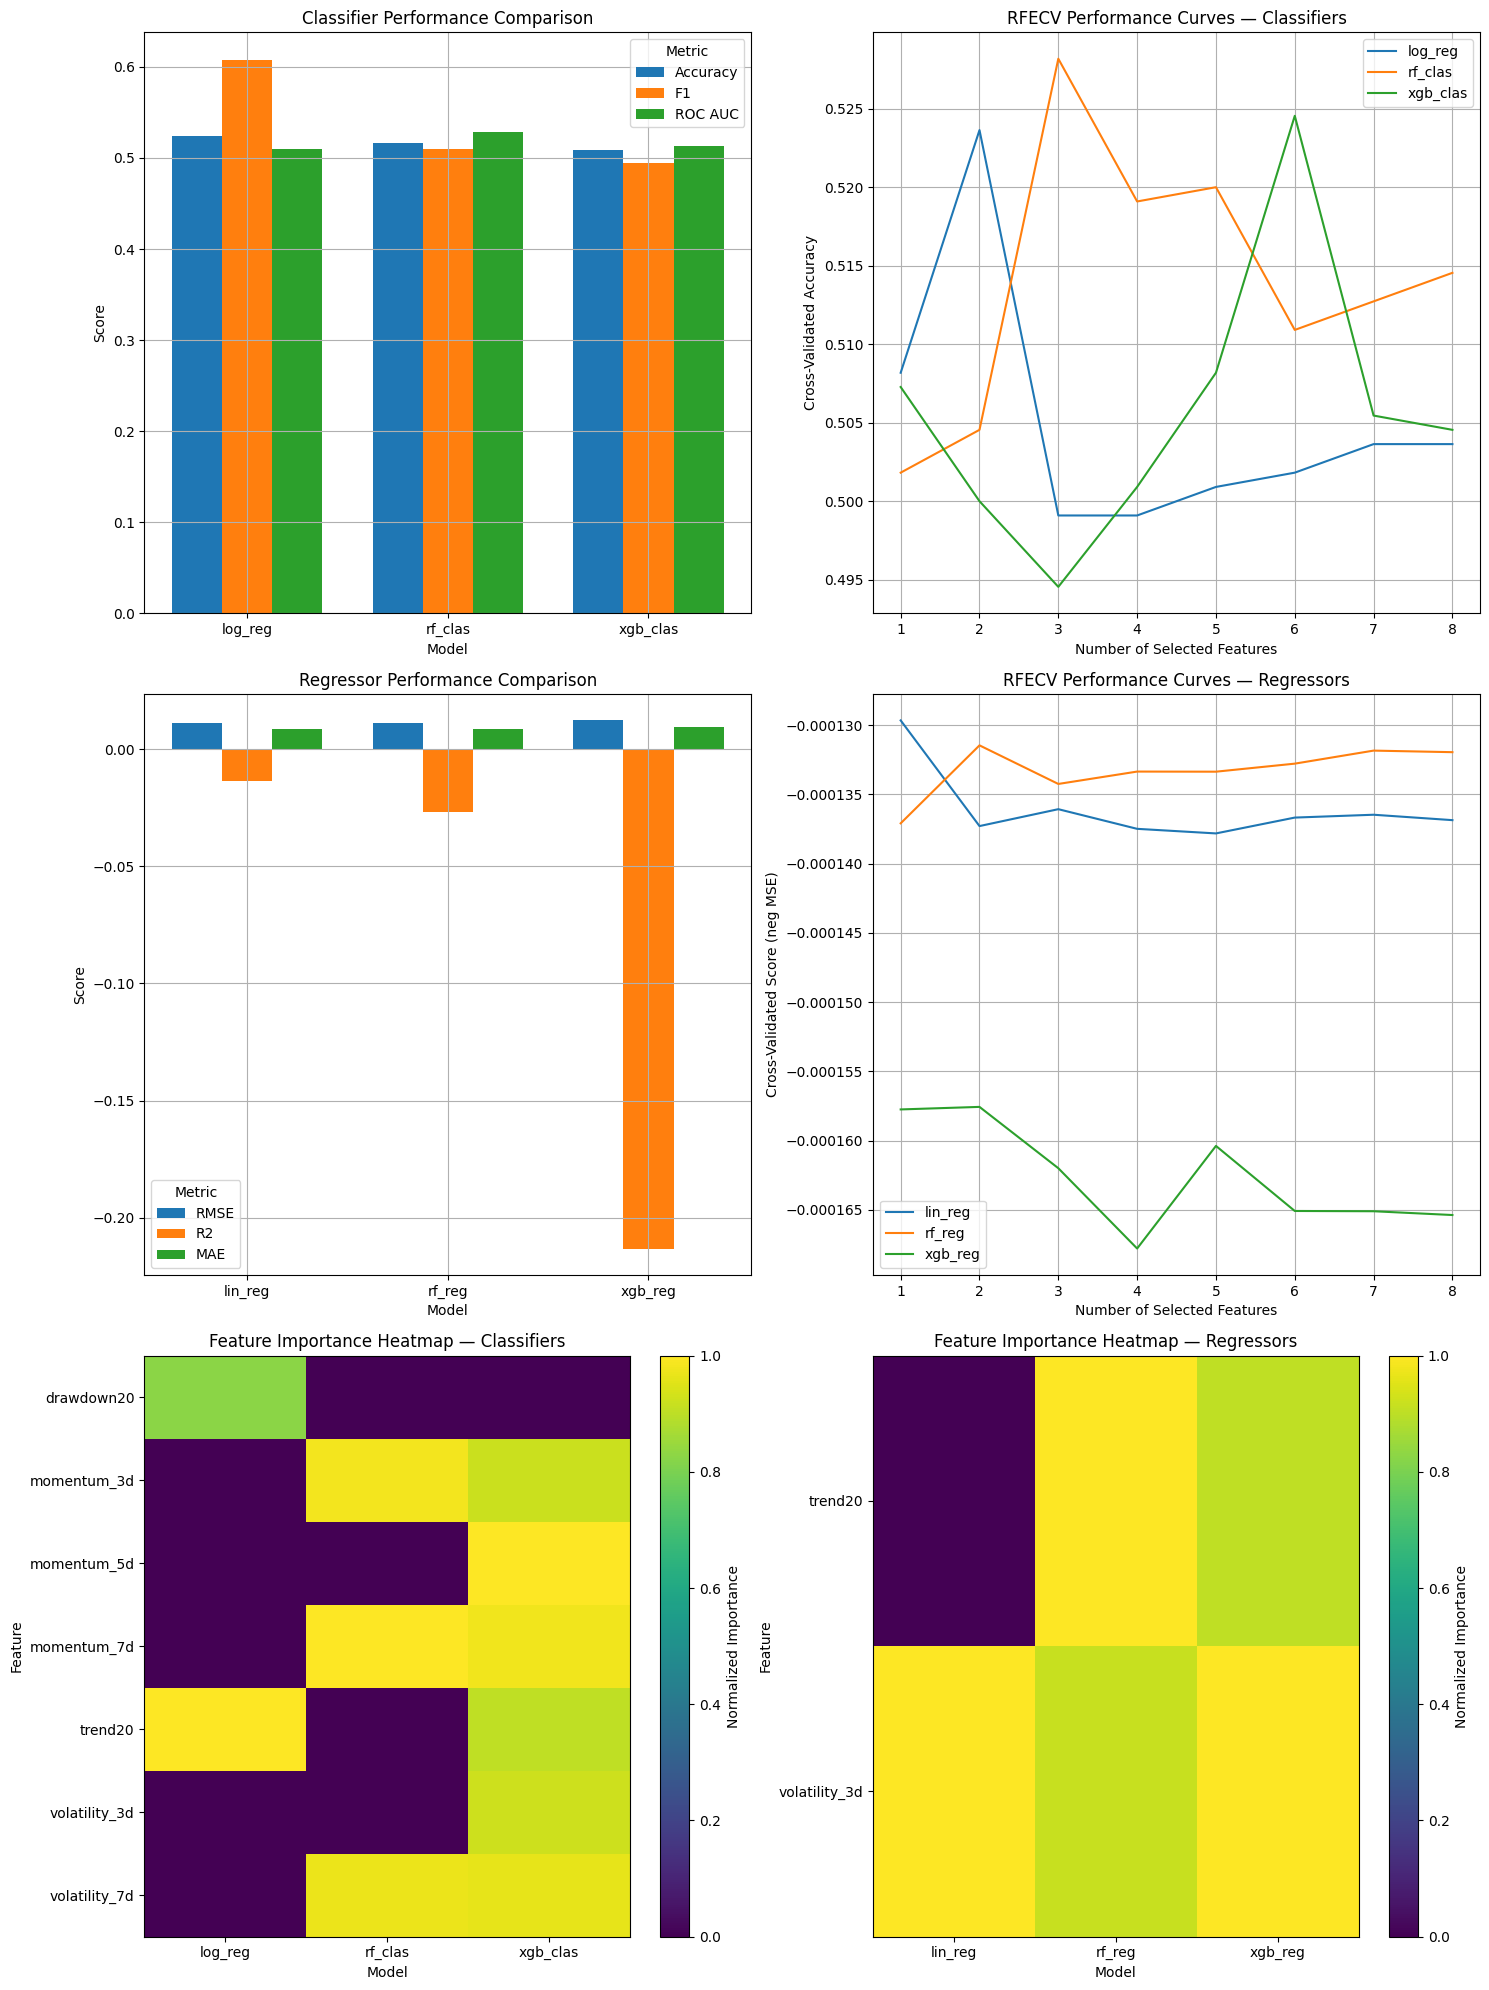

In [22]:
X = pdf[price_features]
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

classifier_results = []
classifier_models = {
    "log_reg": LogisticRegression(max_iter=2000),
    "rf_clas": RandomForestClassifier(
        n_estimators=500,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    ),
    "xgb_clas": XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
    ),
}

rfecv_curves_clf = {}

for name, model in classifier_models.items():
    res = {"model": name}

    rfecv = run_rfecv(model, X_scaled, y_dir, scoring="accuracy")
    best_features = X_scaled.columns[rfecv.support_].tolist()

    model.best_features = best_features
    model.rfecv = rfecv
    rfecv_curves_clf[name] = rfecv.cv_results_["mean_test_score"]

    res.update(run_classification(model, X_scaled[best_features], y_dir)[0])
    classifier_results.append(res)

regressor_results = []
regressor_models = {
    "lin_reg": LinearRegression(),
    "rf_reg": RandomForestRegressor(
        n_estimators=500,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    ),
    "xgb_reg": XGBRegressor(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.03,
    ),
}

rfecv_curves_reg = {}

for name, model in regressor_models.items():
    res = {"model": name}

    rfecv = run_rfecv(model, X_scaled, y_ret, scoring="neg_mean_squared_error")
    best_features = X_scaled.columns[rfecv.support_].tolist()

    model.best_features = best_features
    model.rfecv = rfecv
    rfecv_curves_reg[name] = rfecv.cv_results_["mean_test_score"]

    res.update(run_regression(model, X_scaled[best_features], y_ret)[0])
    regressor_results.append(res)


plt.figure(figsize=(15, 20))

# Classifier plots

df = pl.DataFrame(classifier_results).sort(by="accuracy_mean", descending=True).to_pandas()

x = np.arange(len(df))
width = 0.25

plt.subplot(3, 2, 1)
plt.bar(x - width, df["accuracy_mean"], width, label="Accuracy")
plt.bar(x, df["f1_mean"], width, label="F1")
plt.bar(x + width, df["roc_auc_mean"], width, label="ROC AUC")

plt.xticks(x, df["model"])
plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Classifier Performance Comparison")
plt.legend(title="Metric")
plt.grid()

plt.subplot(3, 2, 2)
for name, scores in rfecv_curves_clf.items():
    plt.plot(range(1, len(scores) + 1), scores, label=name)

plt.title("RFECV Performance Curves — Classifiers")
plt.xlabel("Number of Selected Features")
plt.ylabel("Cross-Validated Accuracy")
plt.legend()
plt.grid()

# Regressor plots

df = pl.DataFrame(regressor_results).sort(by="r2_mean", descending=True).to_pandas()

x = np.arange(len(df))
width = 0.25

plt.subplot(3, 2, 3)
plt.bar(x - width, df["rmse_mean"], width, label="RMSE")
plt.bar(x, df["r2_mean"], width, label="R2")
plt.bar(x + width, df["mae_mean"], width, label="MAE")

plt.xticks(x, df["model"])
plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Regressor Performance Comparison")
plt.legend(title="Metric")
plt.grid()

plt.subplot(3, 2, 4)
for name, scores in rfecv_curves_reg.items():
    plt.plot(range(1, len(scores) + 1), scores, label=name)

plt.title("RFECV Performance Curves — Regressors")
plt.xlabel("Number of Selected Features")
plt.ylabel("Cross-Validated Score (neg MSE)")
plt.legend()
plt.grid()

# Feature importance heatmaps

for model in classifier_models.values():
    model.fit(X_scaled[model.best_features], y_dir)

for model in regressor_models.values():
    model.fit(X_scaled[model.best_features], y_ret)

clf_importance = {}

for name, model in classifier_models.items():
    imp = get_feature_importance(model, model.best_features)
    clf_importance[name] = imp

clf_imp_df = pd.DataFrame(clf_importance).fillna(0)

clf_imp_df = clf_imp_df / clf_imp_df.max()

plt.subplot(3, 2, 5)
plt.imshow(clf_imp_df.values, aspect="auto")

plt.yticks(range(len(clf_imp_df.index)), clf_imp_df.index)
plt.xticks(range(len(clf_imp_df.columns)), clf_imp_df.columns)

plt.title("Feature Importance Heatmap — Classifiers")
plt.xlabel("Model")
plt.ylabel("Feature")
plt.colorbar(label="Normalized Importance")
plt.tight_layout()

reg_importance = {}

for name, model in regressor_models.items():
    imp = get_feature_importance(model, model.best_features)
    reg_importance[name] = imp

reg_imp_df = pd.DataFrame(reg_importance).fillna(0)

reg_imp_df = reg_imp_df / reg_imp_df.max()

plt.subplot(3, 2, 6)
plt.imshow(reg_imp_df.values, aspect="auto")

plt.yticks(range(len(reg_imp_df.index)), reg_imp_df.index)
plt.xticks(range(len(reg_imp_df.columns)), reg_imp_df.columns)

plt.title("Feature Importance Heatmap — Regressors")
plt.xlabel("Model")
plt.ylabel("Feature")
plt.colorbar(label="Normalized Importance")
plt.tight_layout()

plt.show()

### Testing sentiment, tone and price features

/Users/nikolas/Documents/GitHub/MBA-TCC/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/nikolas/Documents/GitHub/MBA-TCC/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/nikolas/Documents/GitHub/MBA-TCC/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/

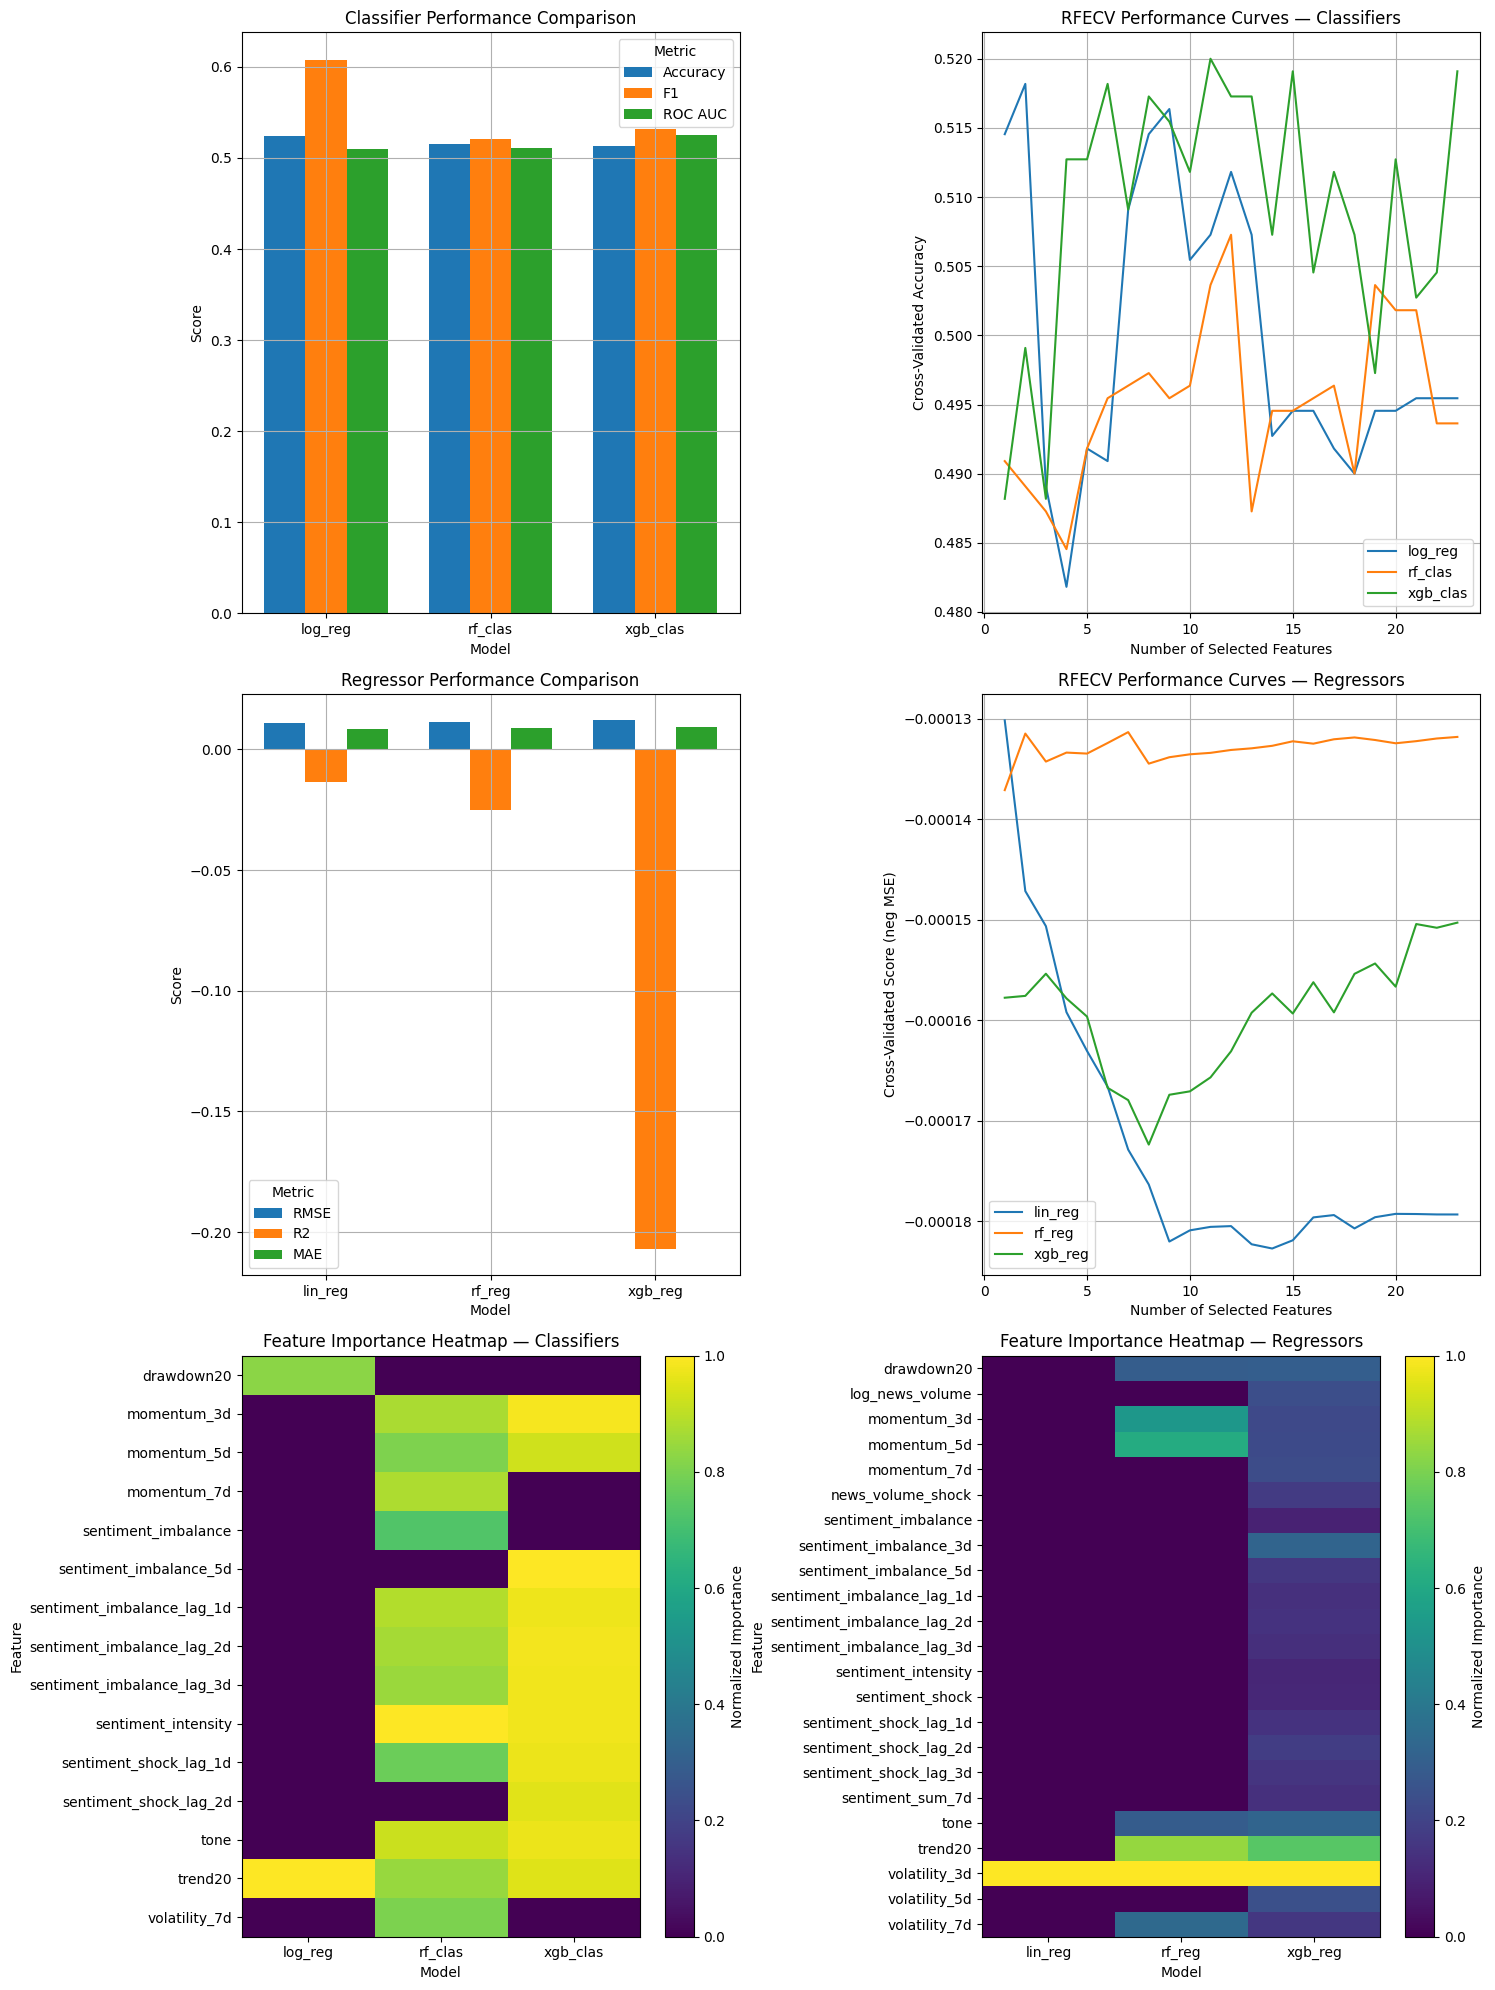

In [23]:
X = pdf[sentiment_features + price_features + gdelt_tone_features]
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

classifier_results = []
classifier_models = {
    "log_reg": LogisticRegression(max_iter=2000),
    "rf_clas": RandomForestClassifier(
        n_estimators=500,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    ),
    "xgb_clas": XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
    ),
}

rfecv_curves_clf = {}

for name, model in classifier_models.items():
    res = {"model": name}

    rfecv = run_rfecv(model, X_scaled, y_dir, scoring="accuracy")
    best_features = X_scaled.columns[rfecv.support_].tolist()

    model.best_features = best_features
    model.rfecv = rfecv
    rfecv_curves_clf[name] = rfecv.cv_results_["mean_test_score"]

    res.update(run_classification(model, X_scaled[best_features], y_dir)[0])
    classifier_results.append(res)

regressor_results = []
regressor_models = {
    "lin_reg": LinearRegression(),
    "rf_reg": RandomForestRegressor(
        n_estimators=500,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    ),
    "xgb_reg": XGBRegressor(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.03,
    ),
}

rfecv_curves_reg = {}

for name, model in regressor_models.items():
    res = {"model": name}

    rfecv = run_rfecv(model, X_scaled, y_ret, scoring="neg_mean_squared_error")
    best_features = X_scaled.columns[rfecv.support_].tolist()

    model.best_features = best_features
    model.rfecv = rfecv
    rfecv_curves_reg[name] = rfecv.cv_results_["mean_test_score"]

    res.update(run_regression(model, X_scaled[best_features], y_ret)[0])
    regressor_results.append(res)


plt.figure(figsize=(15, 20))

# Classifier plots

df = pl.DataFrame(classifier_results).sort(by="accuracy_mean", descending=True).to_pandas()

x = np.arange(len(df))
width = 0.25

plt.subplot(3, 2, 1)
plt.bar(x - width, df["accuracy_mean"], width, label="Accuracy")
plt.bar(x, df["f1_mean"], width, label="F1")
plt.bar(x + width, df["roc_auc_mean"], width, label="ROC AUC")

plt.xticks(x, df["model"])
plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Classifier Performance Comparison")
plt.legend(title="Metric")
plt.grid()

plt.subplot(3, 2, 2)
for name, scores in rfecv_curves_clf.items():
    plt.plot(range(1, len(scores) + 1), scores, label=name)

plt.title("RFECV Performance Curves — Classifiers")
plt.xlabel("Number of Selected Features")
plt.ylabel("Cross-Validated Accuracy")
plt.legend()
plt.grid()

# Regressor plots

df = pl.DataFrame(regressor_results).sort(by="r2_mean", descending=True).to_pandas()

x = np.arange(len(df))
width = 0.25

plt.subplot(3, 2, 3)
plt.bar(x - width, df["rmse_mean"], width, label="RMSE")
plt.bar(x, df["r2_mean"], width, label="R2")
plt.bar(x + width, df["mae_mean"], width, label="MAE")

plt.xticks(x, df["model"])
plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Regressor Performance Comparison")
plt.legend(title="Metric")
plt.grid()

plt.subplot(3, 2, 4)
for name, scores in rfecv_curves_reg.items():
    plt.plot(range(1, len(scores) + 1), scores, label=name)

plt.title("RFECV Performance Curves — Regressors")
plt.xlabel("Number of Selected Features")
plt.ylabel("Cross-Validated Score (neg MSE)")
plt.legend()
plt.grid()

# Feature importance heatmaps

for model in classifier_models.values():
    model.fit(X_scaled[model.best_features], y_dir)

for model in regressor_models.values():
    model.fit(X_scaled[model.best_features], y_ret)

clf_importance = {}

for name, model in classifier_models.items():
    imp = get_feature_importance(model, model.best_features)
    clf_importance[name] = imp

clf_imp_df = pd.DataFrame(clf_importance).fillna(0)

clf_imp_df = clf_imp_df / clf_imp_df.max()

plt.subplot(3, 2, 5)
plt.imshow(clf_imp_df.values, aspect="auto")

plt.yticks(range(len(clf_imp_df.index)), clf_imp_df.index)
plt.xticks(range(len(clf_imp_df.columns)), clf_imp_df.columns)

plt.title("Feature Importance Heatmap — Classifiers")
plt.xlabel("Model")
plt.ylabel("Feature")
plt.colorbar(label="Normalized Importance")
plt.tight_layout()

reg_importance = {}

for name, model in regressor_models.items():
    imp = get_feature_importance(model, model.best_features)
    reg_importance[name] = imp

reg_imp_df = pd.DataFrame(reg_importance).fillna(0)

reg_imp_df = reg_imp_df / reg_imp_df.max()

plt.subplot(3, 2, 6)
plt.imshow(reg_imp_df.values, aspect="auto")

plt.yticks(range(len(reg_imp_df.index)), reg_imp_df.index)
plt.xticks(range(len(reg_imp_df.columns)), reg_imp_df.columns)

plt.title("Feature Importance Heatmap — Regressors")
plt.xlabel("Model")
plt.ylabel("Feature")
plt.colorbar(label="Normalized Importance")
plt.tight_layout()

plt.show()

## Implementing neural networks to try to improve performance

In [24]:
class SequenceDataset(Dataset):
    def __init__(self, X, y, seq_len):
        self.X = X
        self.y = y
        self.seq_len = seq_len

    def __len__(self):
        return len(self.X) - self.seq_len

    def __getitem__(self, idx):
        X_seq = self.X[idx : idx + self.seq_len]
        y_target = self.y[idx + self.seq_len]
        return torch.tensor(X_seq, dtype=torch.float32), torch.tensor(y_target, dtype=torch.float32)

In [25]:
class LSTM_Univariate(nn.Module):
    def __init__(self, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)


class LSTM_Multivariate(nn.Module):
    def __init__(self, num_features, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=num_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)


class LSTM_Seq2Seq(nn.Module):
    def __init__(self, num_features, hidden_size=64, num_layers=2, out_steps=5, teacher_forcing_ratio=0.5):
        super().__init__()
        self.out_steps = out_steps
        self.teacher_forcing_ratio = teacher_forcing_ratio

        self.encoder = nn.LSTM(
            input_size=num_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.decoder = nn.LSTM(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x, y_future=None):
        # y_future shape: (batch, out_steps)
        _, (h, c) = self.encoder(x)

        decoder_input = torch.zeros((x.size(0), 1, 1), device=x.device)

        outputs = []
        for t in range(self.out_steps):
            out, (h, c) = self.decoder(decoder_input, (h, c))
            pred = self.fc(out[:, -1, :])
            outputs.append(pred)

            # 🔥 TEACHER FORCING HERE
            if (y_future is not None) and (torch.rand(1).item() < self.teacher_forcing_ratio):
                decoder_input = y_future[:, t].unsqueeze(1).unsqueeze(2)
            else:
                decoder_input = pred.unsqueeze(1)

        return torch.cat(outputs, dim=1)


class GRU_Multivariate(nn.Module):
    def __init__(self, num_features, hidden_size=64, num_layers=2):
        super().__init__()
        self.gru = nn.GRU(
            input_size=num_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        return self.fc(out)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div)
        pe[:, 1::2] = torch.cos(position * div)
        self.pe = pe.unsqueeze(0)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class TransformerTimeSeries(nn.Module):
    def __init__(self, num_features, d_model=64, nhead=4, num_layers=2, dim_feedforward=128):
        super().__init__()

        self.pos = PositionalEncoding(d_model)

        self.input_proj = nn.Linear(num_features, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos(x)
        out = self.transformer(x)
        out = out[:, -1, :]
        return self.fc(out)

In [26]:
def train_model(model, train_loader, val_loader, epochs=20, lr=1e-3, patience=5):
    device = torch.device("cpu")
    model = model.to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float("inf")
    wait = 0
    best_state = None

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            preds = model(X_batch).squeeze()

            loss = criterion(preds, y_batch)
            loss.backward()

            # 🔥 GRADIENT CLIPPING HERE
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            train_loss += loss.item()

        # ---- VALIDATION ----
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                preds = model(X_batch).squeeze()
                val_loss += criterion(preds, y_batch).item()

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        # 🔥 EARLY STOPPING HERE
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print("Early stopping triggered.")
                break

    # Restore best model
    if best_state is not None:
        model.load_state_dict(best_state)

    return model


In [27]:
def create_loaders(X, y, seq_len=20, batch_size=32, split=0.8):
    split_idx = int(len(X) * split)

    train_ds = SequenceDataset(X[:split_idx], y[:split_idx], seq_len)
    val_ds   = SequenceDataset(X[split_idx:], y[split_idx:], seq_len)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=False)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader

In [28]:
def predict_next(model, X, seq_len):
    model.eval()
    device = next(model.parameters()).device

    seq = torch.tensor(X[-seq_len:], dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = model(seq).cpu().numpy().flatten()[0]
    return pred

def predict_seq2seq(model, X, seq_len, out_steps):
    model.eval()
    device = next(model.parameters()).device

    seq = torch.tensor(X[-seq_len:], dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
        preds = model(seq).cpu().numpy().flatten()
    return preds

def evaluate_model(model, loader):

    preds = []
    trues = []

    model.eval()
    device = next(model.parameters()).device

    with torch.no_grad():
        for Xb, yb in loader:

            Xb = Xb.to(device)

            pred = model(Xb).cpu().numpy().flatten()

            preds.extend(pred)
            trues.extend(yb.numpy())

    preds = np.array(preds)
    trues = np.array(trues)

    rmse = np.sqrt(np.mean((preds - trues) ** 2))
    mae = np.mean(np.abs(preds - trues))
    r2 = r2_score(trues, preds)

    return preds, trues, rmse, mae, r2

def plot_predictions(y_true, y_pred, dates, title="Prediction vs Actual"):
    plt.figure(figsize=(12, 5))
    plt.plot(dates, y_true, label="Actual")
    plt.plot(dates, y_pred, label="Predicted")
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

def plot_multistep(y_true, y_pred, dates, title="Seq2Seq Prediction vs Actual"):
    # if multi-step output, compare first horizon (t+1)
    if y_pred.ndim > 1:
        y_pred = y_pred[:, 0]
    if y_true.ndim > 1:
        y_true = y_true[:, 0]

    plt.figure(figsize=(12, 5))
    plt.plot(dates, y_true, label="Actual")
    plt.plot(dates, y_pred, label="Predicted")
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

def tune_lstm(X, y, seq_len, param_grid, epochs=10):
    results = []

    for hidden in param_grid["hidden_size"]:
        for layers in param_grid["num_layers"]:
            print(f"Testing hidden={hidden}, layers={layers}")

            model = LSTM_Multivariate(
                num_features=X.shape[1],
                hidden_size=hidden,
                num_layers=layers
            )

            train_loader, val_loader = create_loaders(X, y, seq_len)
            trained = train_model(model, train_loader, val_loader, epochs=epochs)

            # Evaluate
            preds = []
            trues = []

            model.eval()
            device = next(model.parameters()).device

            with torch.no_grad():
                for Xb, yb in val_loader:
                    Xb = Xb.to(device)
                    pred = model(Xb).cpu().numpy().flatten()
                    preds.extend(pred)
                    trues.extend(yb.numpy())

            rmse = np.sqrt(np.mean((np.array(preds) - np.array(trues))**2))

            results.append({
                "hidden_size": hidden,
                "num_layers": layers,
                "rmse": rmse
            })

    return pd.DataFrame(results).sort_values("rmse")

def walk_forward_eval(model_class, X, y, seq_len, train_size=0.7, retrain_every=20, **model_kwargs):

    n = len(X)
    split = int(n * train_size)

    preds = []
    trues = []

    # Initial training window
    X_train = X[:split]
    y_train = y[:split]

    train_loader, val_loader = create_loaders(X_train, y_train, seq_len)

    # Instantiate model
    if "num_features" in model_class.__init__.__code__.co_varnames:
        model = model_class(num_features=X.shape[1], **model_kwargs)
    else:
        model = model_class(**model_kwargs)

    model = train_model(model, train_loader, val_loader, epochs=20)

    for i in range(split, n - 1):

        # Predict next step
        pred = predict_next(model, X[:i], seq_len)
        preds.append(pred)
        trues.append(y[i])

        # Expand training window
        if (i - split) % retrain_every == 0:
            X_train = X[:i]
            y_train = y[:i]
            train_loader, val_loader = create_loaders(X_train, y_train, seq_len)
            model = train_model(model, train_loader, val_loader, epochs=10)

    preds = np.array(preds)
    trues = np.array(trues)

    rmse = np.sqrt(np.mean((preds - trues) ** 2))
    return preds, trues, rmse


In [29]:
# --------------------------------
# Prepare neural network dataset
# --------------------------------

seq_len = 20

features = sentiment_features + price_features + gdelt_tone_features

scaler = StandardScaler()
X_multi = scaler.fit_transform(pdf[features])
y = pdf["target_return"].values

X_uni = pdf["return"].values.reshape(-1,1)

# Create loaders
train_loader_multi, val_loader_multi = create_loaders(X_multi, y, seq_len)
train_loader_uni, val_loader_uni = create_loaders(X_uni, y, seq_len)

In [30]:
results = []

models = {
    
    "LSTM_Univariate":
        LSTM_Univariate(),

    "LSTM_Multivariate":
        LSTM_Multivariate(num_features=X_multi.shape[1]),

    "GRU_Multivariate":
        GRU_Multivariate(num_features=X_multi.shape[1]),

    "Transformer":
        TransformerTimeSeries(num_features=X_multi.shape[1]),
}


Training LSTM_Univariate
Epoch 1/20 | Train Loss: 0.0658 | Val Loss: 0.0008
Epoch 2/20 | Train Loss: 0.0103 | Val Loss: 0.0008
Epoch 3/20 | Train Loss: 0.0095 | Val Loss: 0.0007
Epoch 4/20 | Train Loss: 0.0095 | Val Loss: 0.0007
Epoch 5/20 | Train Loss: 0.0095 | Val Loss: 0.0007
Epoch 6/20 | Train Loss: 0.0095 | Val Loss: 0.0007
Epoch 7/20 | Train Loss: 0.0095 | Val Loss: 0.0007
Epoch 8/20 | Train Loss: 0.0096 | Val Loss: 0.0007
Epoch 9/20 | Train Loss: 0.0096 | Val Loss: 0.0007
Epoch 10/20 | Train Loss: 0.0096 | Val Loss: 0.0007
Epoch 11/20 | Train Loss: 0.0096 | Val Loss: 0.0007
Epoch 12/20 | Train Loss: 0.0096 | Val Loss: 0.0008
Early stopping triggered.


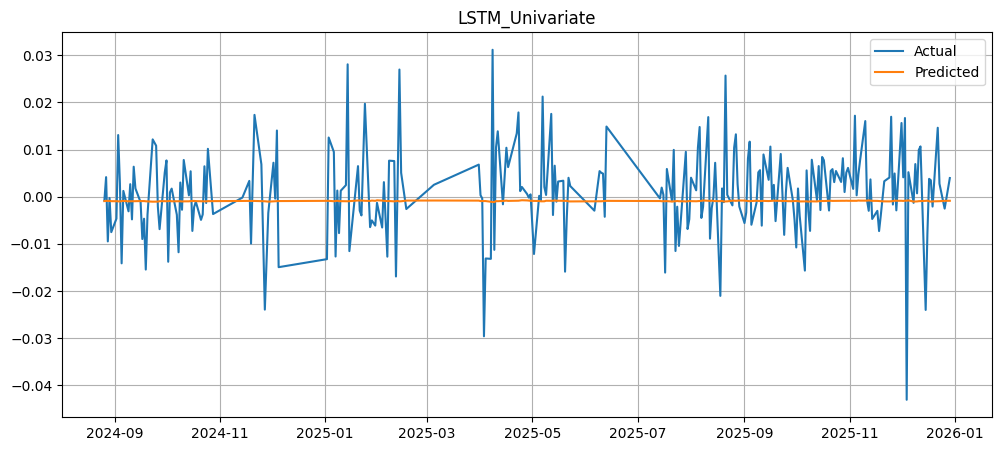


Training LSTM_Multivariate
Epoch 1/20 | Train Loss: 0.0280 | Val Loss: 0.0063
Epoch 2/20 | Train Loss: 0.0223 | Val Loss: 0.0009
Epoch 3/20 | Train Loss: 0.0104 | Val Loss: 0.0009
Epoch 4/20 | Train Loss: 0.0093 | Val Loss: 0.0009
Epoch 5/20 | Train Loss: 0.0095 | Val Loss: 0.0009
Epoch 6/20 | Train Loss: 0.0092 | Val Loss: 0.0008
Epoch 7/20 | Train Loss: 0.0093 | Val Loss: 0.0009
Epoch 8/20 | Train Loss: 0.0093 | Val Loss: 0.0008
Epoch 9/20 | Train Loss: 0.0100 | Val Loss: 0.0010
Epoch 10/20 | Train Loss: 0.0095 | Val Loss: 0.0012
Epoch 11/20 | Train Loss: 0.0104 | Val Loss: 0.0011
Epoch 12/20 | Train Loss: 0.0099 | Val Loss: 0.0008
Epoch 13/20 | Train Loss: 0.0107 | Val Loss: 0.0010
Early stopping triggered.


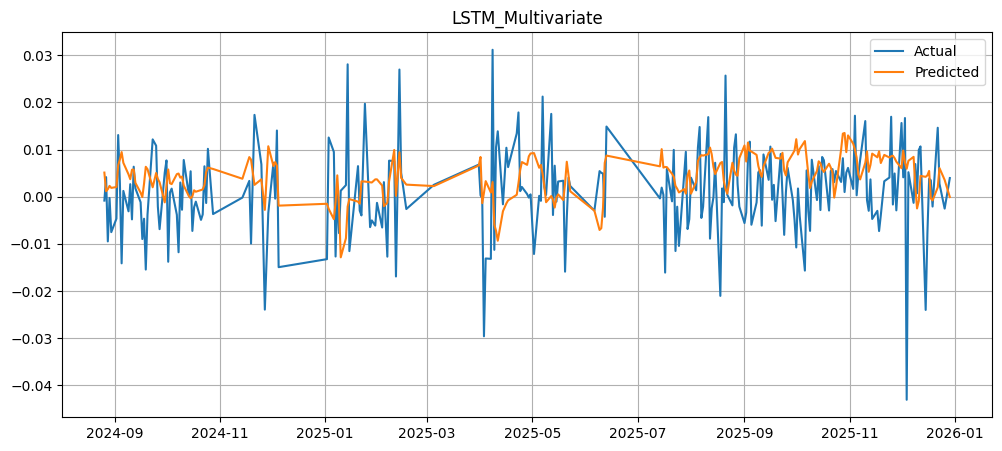


Training GRU_Multivariate
Epoch 1/20 | Train Loss: 0.1489 | Val Loss: 0.0368
Epoch 2/20 | Train Loss: 0.1325 | Val Loss: 0.0070
Epoch 3/20 | Train Loss: 0.0754 | Val Loss: 0.0025
Epoch 4/20 | Train Loss: 0.0385 | Val Loss: 0.0070
Epoch 5/20 | Train Loss: 0.0330 | Val Loss: 0.0028
Epoch 6/20 | Train Loss: 0.0455 | Val Loss: 0.0017
Epoch 7/20 | Train Loss: 0.0412 | Val Loss: 0.0012
Epoch 8/20 | Train Loss: 0.0230 | Val Loss: 0.0011
Epoch 9/20 | Train Loss: 0.0151 | Val Loss: 0.0013
Epoch 10/20 | Train Loss: 0.0130 | Val Loss: 0.0013
Epoch 11/20 | Train Loss: 0.0097 | Val Loss: 0.0008
Epoch 12/20 | Train Loss: 0.0088 | Val Loss: 0.0008
Epoch 13/20 | Train Loss: 0.0087 | Val Loss: 0.0008
Epoch 14/20 | Train Loss: 0.0086 | Val Loss: 0.0008
Epoch 15/20 | Train Loss: 0.0086 | Val Loss: 0.0008
Epoch 16/20 | Train Loss: 0.0085 | Val Loss: 0.0008
Epoch 17/20 | Train Loss: 0.0084 | Val Loss: 0.0008
Early stopping triggered.


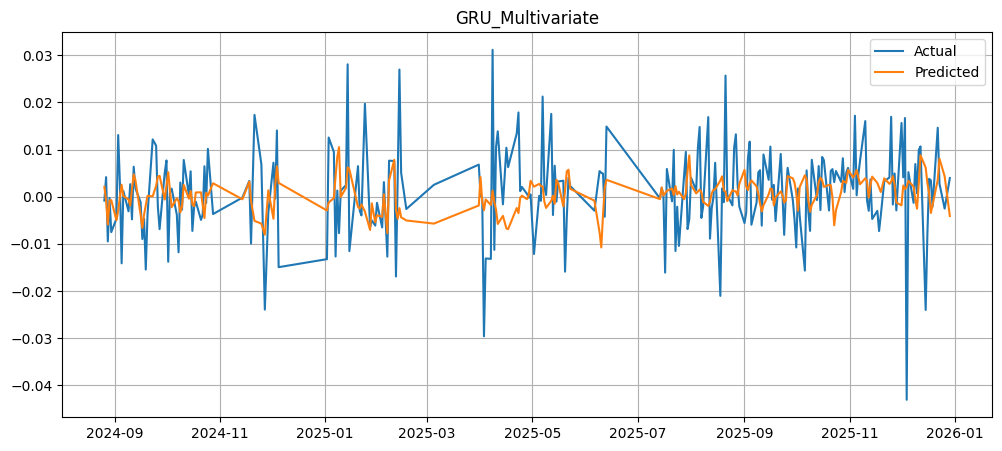


Training Transformer
Epoch 1/20 | Train Loss: 2.6599 | Val Loss: 0.0864
Epoch 2/20 | Train Loss: 0.4645 | Val Loss: 0.0074
Epoch 3/20 | Train Loss: 0.2193 | Val Loss: 0.0141
Epoch 4/20 | Train Loss: 0.0679 | Val Loss: 0.0015
Epoch 5/20 | Train Loss: 0.0897 | Val Loss: 0.0099
Epoch 6/20 | Train Loss: 0.0552 | Val Loss: 0.0024
Epoch 7/20 | Train Loss: 0.0485 | Val Loss: 0.0025
Epoch 8/20 | Train Loss: 0.0439 | Val Loss: 0.0020
Epoch 9/20 | Train Loss: 0.0509 | Val Loss: 0.0016
Early stopping triggered.


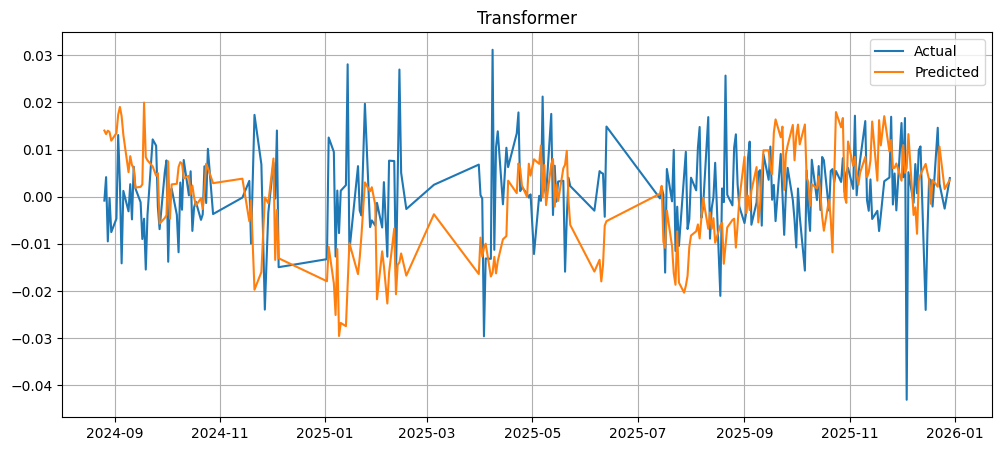

In [31]:
trained_models = {}

for name, model in models.items():

    print(f"\nTraining {name}")

    if "Univariate" in name:
        train_loader = train_loader_uni
        val_loader = val_loader_uni
    else:
        train_loader = train_loader_multi
        val_loader = val_loader_multi

    trained = train_model(
        model,
        train_loader,
        val_loader,
        epochs=20
    )

    preds, trues, rmse, mae, r2 = evaluate_model(trained, val_loader)

    trained_models[name] = trained

    results.append({
        "model": name,
        "rmse": rmse,
        "mae": mae,
        "r2": r2
    })

    plot_predictions(trues, preds, dates=pdf["date"][-len(trues):], title=name)


Training Seq2Seq LSTM
Epoch 1/20 | Train Loss: 0.0138 | Val Loss: 0.0013
Epoch 2/20 | Train Loss: 0.0156 | Val Loss: 0.0009
Epoch 3/20 | Train Loss: 0.0108 | Val Loss: 0.0008
Epoch 4/20 | Train Loss: 0.0111 | Val Loss: 0.0008
Epoch 5/20 | Train Loss: 0.0095 | Val Loss: 0.0008
Epoch 6/20 | Train Loss: 0.0094 | Val Loss: 0.0008
Epoch 7/20 | Train Loss: 0.0092 | Val Loss: 0.0008
Epoch 8/20 | Train Loss: 0.0092 | Val Loss: 0.0008
Epoch 9/20 | Train Loss: 0.0091 | Val Loss: 0.0008
Epoch 10/20 | Train Loss: 0.0091 | Val Loss: 0.0008
Early stopping triggered.


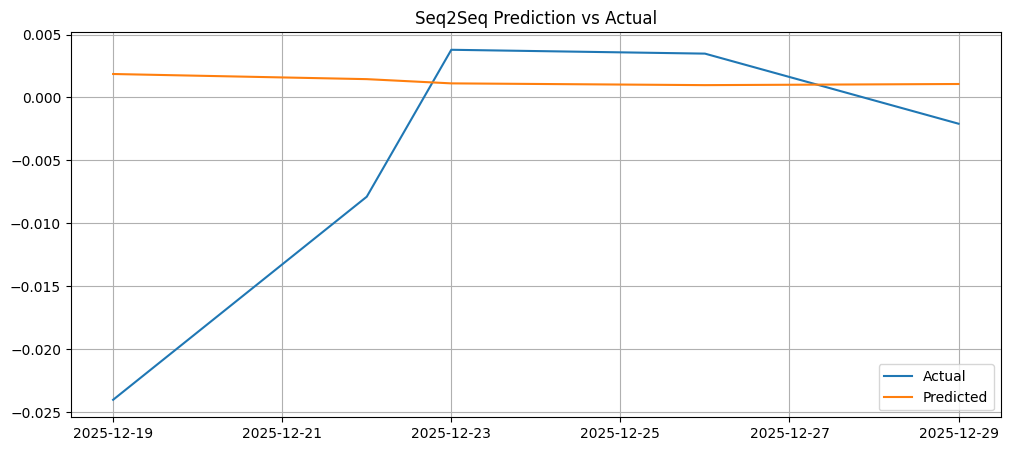

In [32]:
# ----------------------------
# Prepare multi-step targets
# ----------------------------

out_steps = 5

y_seq = np.array([
    pdf["target_return"].shift(-i).values
    for i in range(1, out_steps + 1)
]).T

y_seq = y_seq[:-out_steps]
X_seq = X_multi[:-out_steps]

train_loader_s2s, val_loader_s2s = create_loaders(X_seq, y_seq, seq_len)

print("\nTraining Seq2Seq LSTM")

model_s2s = LSTM_Seq2Seq(
    num_features=X_multi.shape[1],
    out_steps=out_steps
)

trained_s2s = train_model(
    model_s2s,
    train_loader_s2s,
    val_loader_s2s,
    epochs=20
)

multi_preds = predict_seq2seq(
    trained_s2s,
    X_multi,
    seq_len,
    out_steps
)

plot_multistep(y_seq[-len(multi_preds):], multi_preds, dates=pdf["date"][-len(multi_preds):], title="Seq2Seq Prediction vs Actual")

               model      rmse       mae        r2
0    LSTM_Univariate  0.009549  0.007026 -0.044283
2   GRU_Multivariate  0.009903  0.007268 -0.123041
1  LSTM_Multivariate  0.010800  0.008413 -0.335709
3        Transformer  0.014284  0.011049 -1.336544


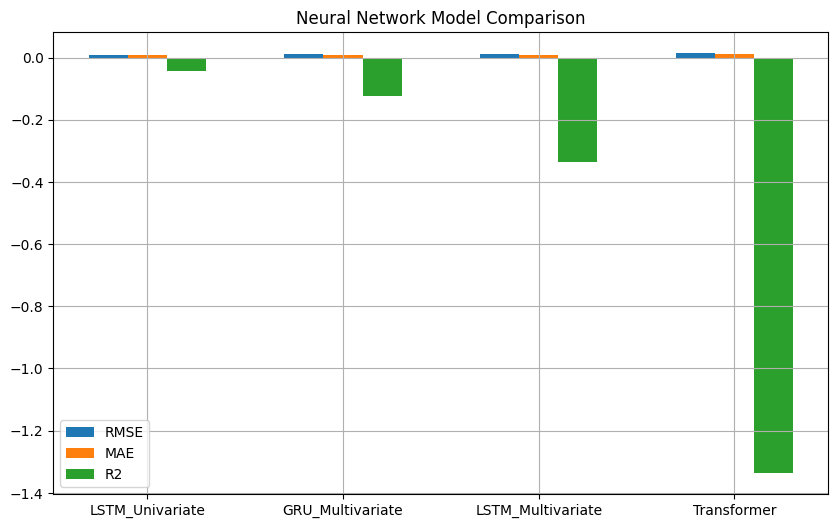

In [33]:
results_df = pd.DataFrame(results).sort_values("rmse")

print(results_df)

plt.figure(figsize=(10,6))

x = np.arange(len(results_df))

plt.bar(x - 0.2, results_df["rmse"], 0.2, label="RMSE")
plt.bar(x, results_df["mae"], 0.2, label="MAE")
plt.bar(x + 0.2, results_df["r2"], 0.2, label="R2")

plt.xticks(x, results_df["model"])
plt.title("Neural Network Model Comparison")
plt.legend()
plt.grid()

plt.show()


Walk-forward evaluation: LSTM
Epoch 1/20 | Train Loss: 0.0256 | Val Loss: 0.0019
Epoch 2/20 | Train Loss: 0.0401 | Val Loss: 0.0013
Epoch 3/20 | Train Loss: 0.0147 | Val Loss: 0.0006
Epoch 4/20 | Train Loss: 0.0096 | Val Loss: 0.0008
Epoch 5/20 | Train Loss: 0.0091 | Val Loss: 0.0007
Epoch 6/20 | Train Loss: 0.0097 | Val Loss: 0.0008
Epoch 7/20 | Train Loss: 0.0091 | Val Loss: 0.0005
Epoch 8/20 | Train Loss: 0.0092 | Val Loss: 0.0010
Epoch 9/20 | Train Loss: 0.0085 | Val Loss: 0.0006
Epoch 10/20 | Train Loss: 0.0104 | Val Loss: 0.0013
Epoch 11/20 | Train Loss: 0.0085 | Val Loss: 0.0008
Epoch 12/20 | Train Loss: 0.0099 | Val Loss: 0.0013
Early stopping triggered.
Epoch 1/10 | Train Loss: 0.0095 | Val Loss: 0.0006
Epoch 2/10 | Train Loss: 0.0111 | Val Loss: 0.0009
Epoch 3/10 | Train Loss: 0.0130 | Val Loss: 0.0011
Epoch 4/10 | Train Loss: 0.0108 | Val Loss: 0.0006
Epoch 5/10 | Train Loss: 0.0094 | Val Loss: 0.0005
Epoch 6/10 | Train Loss: 0.0088 | Val Loss: 0.0016
Epoch 7/10 | Train Los

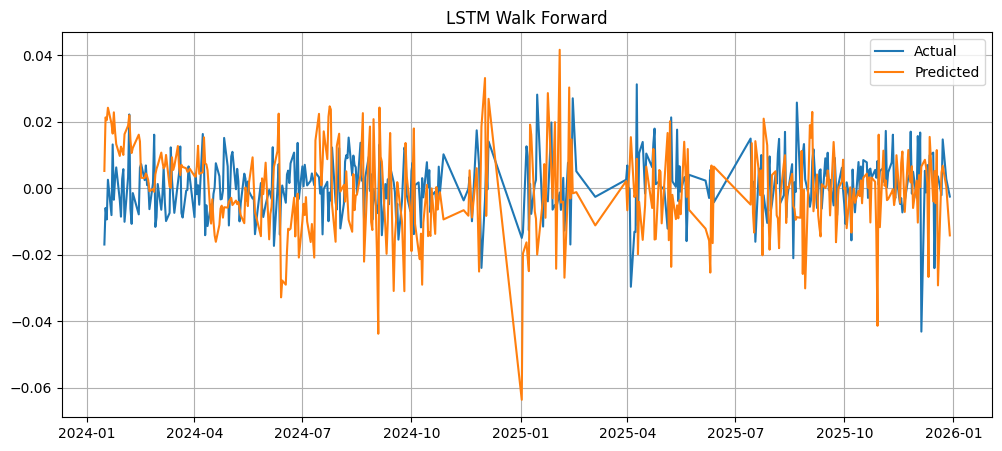


Walk-forward evaluation: GRU
Epoch 1/20 | Train Loss: 0.2717 | Val Loss: 0.0350
Epoch 2/20 | Train Loss: 0.3573 | Val Loss: 0.0249
Epoch 3/20 | Train Loss: 0.2288 | Val Loss: 0.0101
Epoch 4/20 | Train Loss: 0.1321 | Val Loss: 0.0018
Epoch 5/20 | Train Loss: 0.0517 | Val Loss: 0.0006
Epoch 6/20 | Train Loss: 0.0168 | Val Loss: 0.0009
Epoch 7/20 | Train Loss: 0.0122 | Val Loss: 0.0008
Epoch 8/20 | Train Loss: 0.0099 | Val Loss: 0.0008
Epoch 9/20 | Train Loss: 0.0090 | Val Loss: 0.0006
Epoch 10/20 | Train Loss: 0.0083 | Val Loss: 0.0006
Epoch 11/20 | Train Loss: 0.0083 | Val Loss: 0.0005
Epoch 12/20 | Train Loss: 0.0079 | Val Loss: 0.0005
Epoch 13/20 | Train Loss: 0.0079 | Val Loss: 0.0005
Epoch 14/20 | Train Loss: 0.0078 | Val Loss: 0.0005
Epoch 15/20 | Train Loss: 0.0077 | Val Loss: 0.0005
Epoch 16/20 | Train Loss: 0.0077 | Val Loss: 0.0005
Epoch 17/20 | Train Loss: 0.0076 | Val Loss: 0.0005
Epoch 18/20 | Train Loss: 0.0075 | Val Loss: 0.0005
Epoch 19/20 | Train Loss: 0.0075 | Val Loss

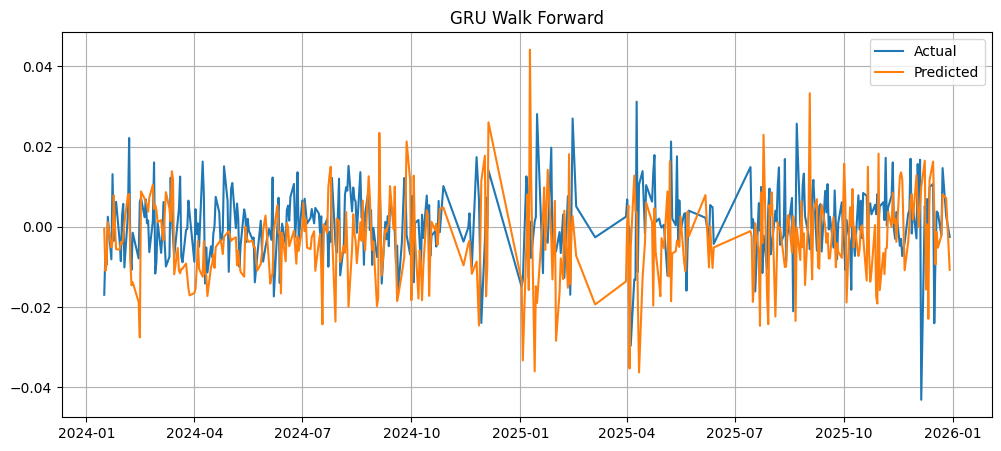

In [34]:
wf_results = []

for name, model_class in [

    ("LSTM", LSTM_Multivariate),
    ("GRU", GRU_Multivariate),
]:

    print(f"\nWalk-forward evaluation: {name}")

    preds, trues, rmse = walk_forward_eval(
        model_class,
        X_multi,
        y,
        seq_len=seq_len,
        hidden_size=64,
        num_layers=2
    )

    wf_results.append({
        "model": name,
        "rmse": rmse
    })

    plot_predictions(trues, preds, dates=pdf["date"][-len(trues):], title=f"{name} Walk Forward")